 # IBM Quantum Calibration Data Analysis

 This notebook presents a **quantitative exploratory data analysis** (EDA) of IBM quantum machine calibration data, including single-qubit and gate-level metrics.

 ## 1. Load Data

In [79]:
import pandas as pd
import gzip
import ujson

def load_jsonl_gz(path):
    rows = []
    with gzip.open(path, "rt") as f:
        for line in f:
            d = ujson.loads(line)
            base = {"backend": d["backend"], "scrape_time": d["scrape_time"]}
            if "qubit" in d :
                row = base | {"qubit": d["qubit"]} | d["properties"]
            else:
                row = base | {"gate": d["gate"], "qubits": tuple(d["qubits"])} | d["properties"]
            rows.append(row)
    df = pd.json_normalize(rows)
    df['scrape_time'] = pd.to_datetime(df['scrape_time'], format="%Y-%m-%d_%H-%M-%S",utc=True)
    if 'qubit' in df.columns:
        df['entity'] = df['backend'] + "|" + df['qubit'].astype(str)
    else:
        df['entity']  = df['backend'] + "|" + df['gate'] + "|" + df['qubits'].apply(lambda x: ",".join(map(str, x)))
        df["arity"] = df["qubits"].apply(len)
        df["qubit"] = df["qubits"].apply(lambda x: x[0] if len(x)==1 else [int(q) for q in x])
    return df

df_qubit = load_jsonl_gz("../data/merged/qubits.json.gz")
df_gate  = load_jsonl_gz("../data/merged/gates.json.gz")




In [128]:
df_qubit[["backend", "scrape_time"]].groupby(["backend"]).max()

,scrape_time
backend,
ibm_fez,2026-03-03 08:10:45+00:00
ibm_marrakesh,2026-03-03 06:03:15+00:00
ibm_torino,2026-03-02 22:09:22+00:00


 ## 2. Apply time weighting for meaningfull statistics

Updating scraping days

In [ ]:
import numpy as np

def update_workflow_runs_csv(csv_path, owner, repo, workflow_id, token):
    import requests
    import pandas as pd

    df_runs = pd.read_csv(csv_path)

    headers = {
    "Authorization": f"Bearer {token}",
    "Accept": "application/vnd.github+json",
    }

    # ====== FETCH WORKFLOW RUNS ======
    url = f"https://api.github.com/repos/{owner}/{repo}/actions/workflows/{workflow_id}/runs?per_page=100"

    runs_data = []
    page = 1

    while True:
        print(f"Fetching page {page}...")
        response = requests.get(url + f"&page={page}", headers=headers)
        response.raise_for_status()
        data = response.json()
        runs = data.get("workflow_runs", [])
        if not runs:
            break
        for run in runs:
            runs_data.append({
                "id": run["id"],
                "created_at": run["created_at"],
                "status": run["conclusion"]
            })
        page += 1

    # ====== CONVERT TO DATAFRAME ======
    df = pd.DataFrame(runs_data)
    df["created_at"] = pd.to_datetime(df["created_at"])

    # Merge with existing data
    df_combined = pd.concat([df_runs, df]).drop_duplicates(subset=["id"]).reset_index(drop=True)
    df_combined["created_at"] = pd.to_datetime(df_combined["created_at"])

    df_combined.to_csv(csv_path, index=False)


    return df_combined

df_scraping = update_workflow_runs_csv()
df_scraping = pd.read_csv("workflow_runs.csv")
df_scraping["created_at"] = pd.to_datetime(df_scraping["created_at"])


Fetching page 1...
Fetching page 2...
Fetching page 3...
Fetching page 4...
Fetching page 5...
Fetching page 6...
Fetching page 7...
Fetching page 8...
Fetching page 9...
Fetching page 10...
Fetching page 11...
Fetching page 12...
Fetching page 13...
Fetching page 14...
Fetching page 15...
Fetching page 16...
Fetching page 17...
Fetching page 18...
Fetching page 19...
Fetching page 20...
Fetching page 21...
Fetching page 22...
Fetching page 23...
Fetching page 24...
Fetching page 25...
Fetching page 26...
Fetching page 27...
Fetching page 28...
Fetching page 29...
Fetching page 30...
Fetching page 31...
Fetching page 32...
Fetching page 33...
Fetching page 34...
Fetching page 35...
Fetching page 36...
Fetching page 37...
Fetching page 38...
Fetching page 39...


In [90]:
df_scraping["date"] = df_scraping["created_at"].dt.date
scrape_days = np.sort(df_scraping[df_scraping["status"] != "failure"]["date"].unique())

In [91]:
from datetime import timedelta, datetime

def active_seconds_between(t0, t1, active_days_set):
    """
    Compute how many seconds between t0 and t1 fall on active scraping days.
    """

    if pd.isna(t1) or t1 <= t0:
        return 0.0

    total = 0.0
    day = t0.date()
    tz = t0.tz

    while day <= t1.date():

        if day in active_days_set:
            # Build day boundaries safely
            day_start = pd.Timestamp(datetime.combine(day, datetime.min.time()))
            if tz is not None:
                day_start = day_start.tz_localize(tz)

            day_end = day_start + timedelta(days=1)

            start = max(t0, day_start)
            end   = min(t1, day_end)

            if end > start:
                total += (end - start).total_seconds()

        day += timedelta(days=1)

    return total



def add_time_weight_from_calendar(
    df,
    scrape_days,
    ignore_gates=None,
):
    """
    Add duration_sec using only periods where scraping was active.

    Parameters:
        df : DataFrame
        scrape_days : iterable of datetime.date
        ignore_gates : list of gate names (optional)
    """

    ignore_gates = ignore_gates or []
    active_days_set = set(scrape_days)

    df = df.sort_values(["entity", "scrape_time"]).copy()
    df["next_time"] = df.groupby("entity")["scrape_time"].shift(-1)

    now = pd.Timestamp.utcnow()
    df["next_time"] = df["next_time"].fillna(now)

    # Allocate output
    durations = np.zeros(len(df))

    # Loop only once over rows (acceptable because entities are already sparse)
    for i, (t0, t1) in enumerate(zip(df["scrape_time"], df["next_time"])):
        durations[i] = active_seconds_between(t0, t1, active_days_set)

    df["duration_sec"] = durations

    # Optional: ignore duration computation for some gates
    if "gate" in df.columns and ignore_gates:
        mask = df["gate"].isin(ignore_gates)
        df.loc[mask, "duration_sec"] = (df.loc[mask, "next_time"] - df.loc[mask, "scrape_time"]).dt.total_seconds()

    # Remove invalid durations
    df = df[df["duration_sec"] > 0]

    return df



# scrape_days = list of datetime.date when scraper was active

df_qubit = add_time_weight_from_calendar(
    df_qubit,
    scrape_days,
)

df_gate = add_time_weight_from_calendar(
    df_gate,
    scrape_days,
    ignore_gates=["rz", "reset"],
)


In [92]:
df_gate.tail()

,backend,scrape_time,gate,qubits,gate_error,gate_length,entity,arity,qubit,next_time,duration_sec
395442,ibm_torino,2026-02-16 04:36:31+00:00,x,"(99,)",0.000228,3.200000e-08,ibm_torino|x|99,1,99,2026-02-16 21:18:44+00:00,6.013300e+04
402001,ibm_torino,2026-02-16 21:18:44+00:00,x,"(99,)",0.000226,3.200000e-08,ibm_torino|x|99,1,99,2026-02-18 13:32:20+00:00,1.448160e+05
413249,ibm_torino,2026-02-18 13:32:20+00:00,x,"(99,)",0.000209,3.200000e-08,ibm_torino|x|99,1,99,2026-02-18 13:33:20+00:00,6.000000e+01
413729,ibm_torino,2026-02-18 13:33:20+00:00,x,"(99,)",0.000226,3.200000e-08,ibm_torino|x|99,1,99,2026-02-18 13:35:20+00:00,1.200000e+02
414209,ibm_torino,2026-02-18 13:35:20+00:00,x,"(99,)",0.000209,3.200000e-08,ibm_torino|x|99,1,99,2026-03-03 12:36:14.650307+00:00,1.119655e+06


 ## Preiminary analysis

In [93]:
# -----------------------------
# Dataset overview
# -----------------------------
print("Qubit rows:", len(df_qubit))
print("\nGate rows :", len(df_gate))
print("\nBackends  :", df_qubit["backend"].nunique())
print("\nQubits    :\n", df_qubit[["backend","qubit"]].groupby(["backend"]).nunique())
print("\nGate entities:\n", df_gate[["backend","entity"]].groupby(["backend"]).nunique())
print("\nQubit updates:", df_qubit[["backend","qubit"]].groupby(["backend"]).size())
print("\nGate updates:", df_gate[["backend","entity"]].groupby(["backend"]).size())

display(
    df_qubit[["scrape_time"]]
    .agg(["min", "max"])
)

display(
    df_qubit.isna().mean().sort_values(ascending=False)
)


Qubit rows: 231425

Gate rows : 482002

Backends  : 3

Qubits    :
                qubit
backend             
ibm_fez          156
ibm_marrakesh    156
ibm_torino       133

Gate entities:
                entity
backend              
ibm_fez          1952
ibm_marrakesh    1796
ibm_torino       1531

Qubit updates: backend
ibm_fez          82718
ibm_marrakesh    80410
ibm_torino       68297
dtype: int64

Gate updates: backend
ibm_fez          177509
ibm_marrakesh    166244
ibm_torino       138249
dtype: int64


,scrape_time
min,2025-11-18 23:19:51+00:00
max,2026-03-03 08:10:45+00:00


readout_length      0.001348
backend             0.000000
qubit               0.000000
scrape_time         0.000000
T1                  0.000000
T2                  0.000000
prob_meas0_prep1    0.000000
readout_error       0.000000
prob_meas1_prep0    0.000000
entity              0.000000
next_time           0.000000
duration_sec        0.000000
dtype: float64

### Dataset size and coverage

- Total qubit records: **N = 80680**
- Total gate records: **N = 182251**
- Number of backends: **3**
- Observation window: from **2025-11-18 23:19:51+00:00** to **2026-01-19 13:28:46+00:00**.

Missing values are non-negligible for some metrics (notably readout_length and some error fields).
This motivates:
- weighted statistics instead of naive averages,
- dropping incomplete rows in correlation and PCA analysis.


 ## 3. Qubit-Level Analysis

In [94]:
import numpy as np

def weighted_quantile(values, weights, quantiles):
    """
    Compute weighted quantiles.
    quantiles in [0,1]
    """
    values = np.asarray(values)
    weights = np.asarray(weights)

    mask = np.isfinite(values) & np.isfinite(weights)
    values = values[mask]
    weights = weights[mask]

    if len(values) == 0:
        return [np.nan] * len(quantiles)

    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]

    cumulative = np.cumsum(weights)
    cumulative /= cumulative[-1]

    return np.interp(quantiles, cumulative, values)

def weighted_box_stats(df, value_col, weight_col="duration_sec"):
    q1, med, q3 = weighted_quantile(
        df[value_col],
        df[weight_col],
        [0.25, 0.50, 0.75]
    )

    iqr = q3 - q1
    whisker_low  = q1 - 1.5 * iqr
    whisker_high = q3 + 1.5 * iqr

    return dict(
        q1=q1,
        med=med,
        q3=q3,
        whislo=whisker_low,
        whishi=whisker_high
    )


In [95]:
nan_mask = df_qubit.isna().any(axis=1)
df_nan = df_qubit[nan_mask]

In [96]:
nan_by_backend = (
    df_qubit.assign(has_nan=df_qubit.isna().any(axis=1))
      .groupby(["scrape_time","backend","qubit"])["has_nan"]
      .agg(["count", "sum", "mean"])
      .sort_values("mean", ascending=False)
)
nan_by_backend

count  sum  mean
scrape_time               backend qubit                  
2026-01-16 12:43:54+00:00 ibm_fez 141        1    1   1.0
                                  142        1    1   1.0
                                  143        1    1   1.0
                                  144        1    1   1.0
                                  145        1    1   1.0
...                                        ...  ...   ...
2025-11-18 23:19:51+00:00 ibm_fez 12         1    0   0.0
                                  13         1    0   0.0
                                  14         1    0   0.0
                                  15         1    0   0.0
                                  0          1    0   0.0

[231425 rows x 3 columns]

In [97]:
df_qubit.isna().mean().sort_values(ascending=False)

readout_length      0.001348
backend             0.000000
qubit               0.000000
scrape_time         0.000000
T1                  0.000000
T2                  0.000000
prob_meas0_prep1    0.000000
readout_error       0.000000
prob_meas1_prep0    0.000000
entity              0.000000
next_time           0.000000
duration_sec        0.000000
dtype: float64

T1
	ibm_fez : {'q1': np.float64(0.0001132772649657329), 'med': np.float64(0.0001442075399845698), 'q3': np.float64(0.0001751201379425417), 'whislo': np.float64(2.0512955500519685e-05), 'whishi': np.float64(0.0002678844474077549), 'label': 'ibm_fez', 'color': '#a65628'}
	ibm_marrakesh : {'q1': np.float64(0.0001391681235531943), 'med': np.float64(0.00018419299341355065), 'q3': np.float64(0.000250050210883354), 'whislo': np.float64(-2.7155007442045278e-05), 'whishi': np.float64(0.00041637334187859357), 'label': 'ibm_marrakesh', 'color': '#377eb8'}
	ibm_torino : {'q1': np.float64(0.00012574565201997607), 'med': np.float64(0.0001795038790133282), 'q3': np.float64(0.00022607386992157645), 'whislo': np.float64(-2.4746674832424502e-05), 'whishi': np.float64(0.00037656619677397705), 'label': 'ibm_torino', 'color': '#dede00'}
T2
	ibm_fez : {'q1': np.float64(5.32004039871337e-05), 'med': np.float64(0.00010221396700473), 'q3': np.float64(0.00014533481458258623), 'whislo': np.float64(-8.50012119060

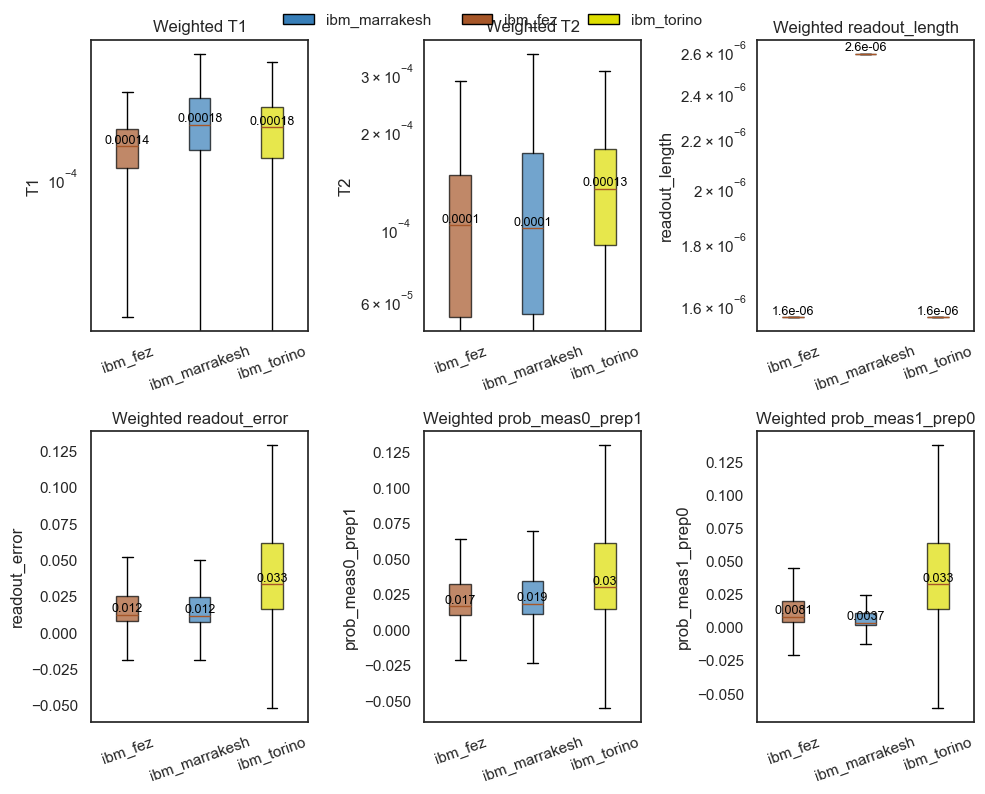

In [98]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

metrics = ["T1", "T2", "readout_length",
           "readout_error", "prob_meas0_prep1", "prob_meas1_prep0"]

color_palette = {"ibm_marrakesh" : '#377eb8',
                 "ibm_fez" : '#a65628',
                 "ibm_torino" : '#dede00'}

backends = sorted(df_qubit["backend"].unique())

fig, axes = plt.subplots(2, len(metrics)//2, figsize=(10, 8), sharex=False)

for idx,metric in enumerate(metrics):

    ax = axes.flatten()[idx]

    stats = []
    print(metric)

    for backend in backends:
        g = df_qubit[
            (df_qubit["backend"] == backend) &
            (df_qubit[metric].notna())
        ]

        if g.empty:
            stats.append(dict(q1=np.nan, med=np.nan, q3=np.nan,
                              whislo=np.nan, whishi=np.nan))
            continue

        s = weighted_box_stats(g, metric)
        s["label"] = backend
        s["color"] = color_palette.get(backend)
        stats.append(s)
        print(f"\t{backend} : {s}")

    bp = ax.bxp(stats, showfliers=False, patch_artist=True)

    for box, s in zip(bp["boxes"], stats):
        if s.get("color") is not None:
            box.set_facecolor(s["color"])
            box.set_alpha(0.7)


    # ---- annotate medians
    for k, s in enumerate(stats, start=1):
        if np.isfinite(s["med"]):
            ax.text(
                k,
                s["med"],
                f"{s['med']:.2g}",
                ha="center",
                va="bottom",
                fontsize=9,
                color="black"
            )

    ax.set_title(f"Weighted {metric}")
    ax.set_ylabel(metric)

    if metric in ["T1", "T2", "readout_length"]:
        ax.set_yscale("log")

    ax.tick_params(axis="x", rotation=20)

    

legend_handles = [
    Patch(facecolor=color, edgecolor="black", label=backend)
    for backend, color in color_palette.items()
    if backend in backends
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=len(legend_handles),
    frameon=False
)


plt.tight_layout()
plt.show()


### Weighted distribution of qubit metrics

Each boxplot represents the **time-weighted distribution** of a metric across all qubits of a backend.
Weighting by active scraping duration reduces bias from irregular sampling.

Observations:
- T1 and T2 span roughly one order of magnitude across backends.
- Measurement-related errors exhibit tighter distributions but show backend-dependent offsets.
- Log scaling is required due to heavy-tailed distributions.

Interpretation:
- Higher T1/T2 indicate better coherence.
- Lower readout_error and preparation error indicate better classical control quality.


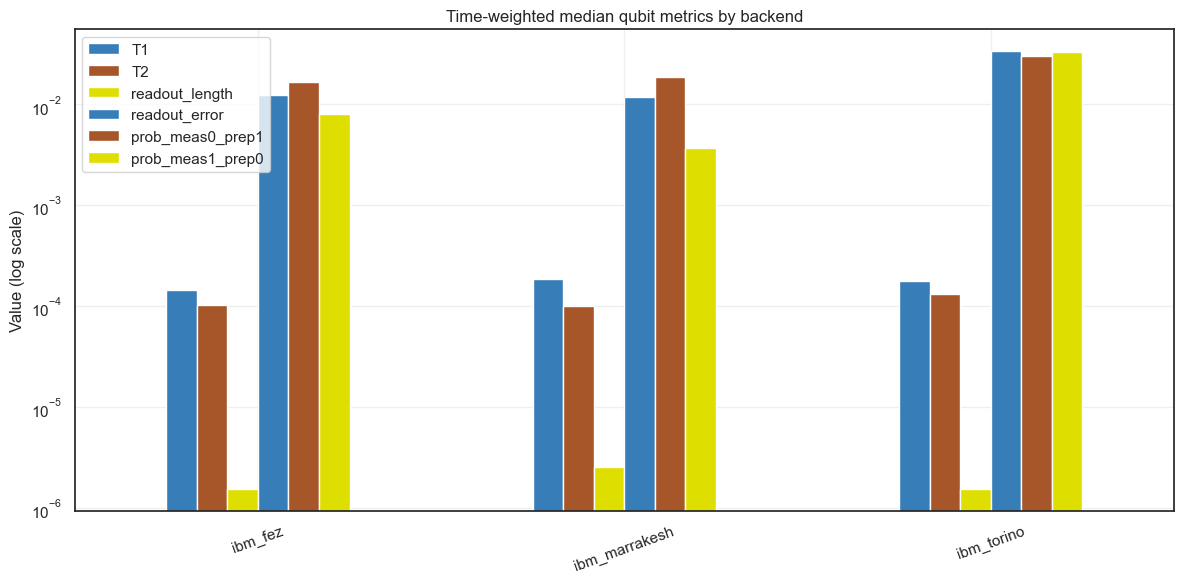

In [99]:
weighted_medians = {}

for backend, g in df_qubit.groupby("backend"):
    medians = []
    for metric in metrics:
        val = g[metric]
        wgt = g["duration_sec"]
        med = weighted_quantile(val, wgt, [0.5])[0]
        medians.append(med)
    weighted_medians[backend] = medians

# Convert to DataFrame
df_medians = pd.DataFrame(weighted_medians, index=metrics).T

# Plot
df_medians.plot(kind="bar", figsize=(12,6))
plt.yscale("log")
plt.title("Time-weighted median qubit metrics by backend")
plt.ylabel("Value (log scale)")
plt.xticks(rotation=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




### Time-weighted median comparison

This plot summarizes each backend using **time-weighted medians**.

This provides a robust backend-level indicator while suppressing transient spikes.

Caution:
- Median hides multimodality.
- Backend heterogeneity at qubit level is not visible here.


 ### 3.3 Correlations


Top correlations for ibm_fez:


readout_error     prob_meas1_prep0    0.922676
prob_meas1_prep0  readout_error       0.922676
prob_meas0_prep1  readout_error       0.837663
readout_error     prob_meas0_prep1    0.837663
prob_meas0_prep1  prob_meas1_prep0    0.570090
dtype: float64


Top correlations for ibm_marrakesh:


readout_error     prob_meas0_prep1    0.864109
prob_meas0_prep1  readout_error       0.864109
prob_meas1_prep0  readout_error       0.658547
readout_error     prob_meas1_prep0    0.658547
T1                T2                  0.499828
dtype: float64


Top correlations for ibm_torino:


readout_error     prob_meas0_prep1    0.895423
prob_meas0_prep1  readout_error       0.895423
prob_meas1_prep0  readout_error       0.748947
readout_error     prob_meas1_prep0    0.748947
T1                T2                  0.584078
dtype: float64

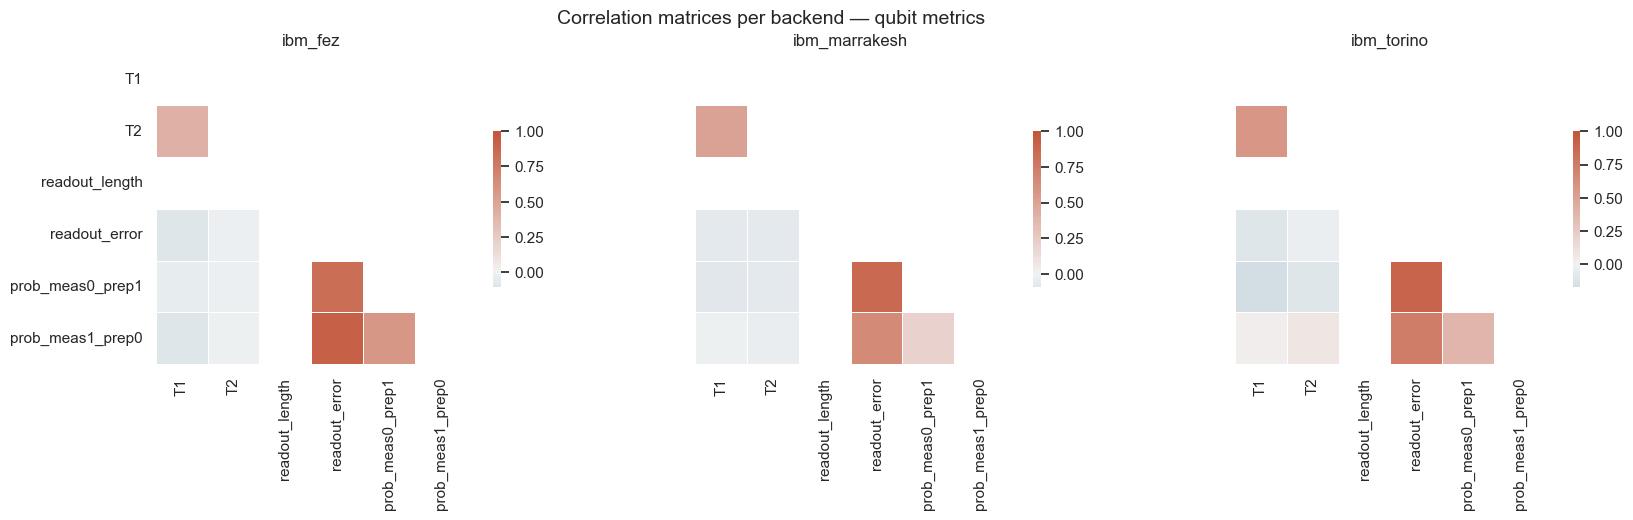

In [100]:
import seaborn as sns
import numpy as np

sns.set_theme(style="white")

backends = sorted(df_qubit["backend"].unique())
n = len(backends)

fig, axes = plt.subplots(1, n, figsize=(6*n, 5), sharey=True)

if n == 1:
    axes = [axes]

for ax, backend in zip(axes, backends):
    tmp = df_qubit[df_qubit["backend"] == backend][metrics].dropna()
    corr = tmp.corr()
    abs_corr = corr.abs().unstack().sort_values(ascending=False)
    top_pairs = abs_corr[abs_corr < 1].head(5)

    print(f"\nTop correlations for {backend}:")
    display(top_pairs)

    mask = np.triu(np.ones_like(corr, dtype=bool))
    cmap = sns.diverging_palette(230, 20, as_cmap=True)

    sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=ax)
    ax.set_title(f"{backend}")

fig.suptitle("Correlation matrices per backend — qubit metrics", fontsize=14)

plt.tight_layout()
plt.show()


### Correlation structure

Correlation matrices reveal coupling between physical quantities.

Observations:
- T1 and T2 are positively correlated.
- Error metrics are strongly correlated.
- Readout error correlates weakly with coherence metrics.

Note:
Correlation does not imply causation. Many effects are hardware- and calibration-dependent.


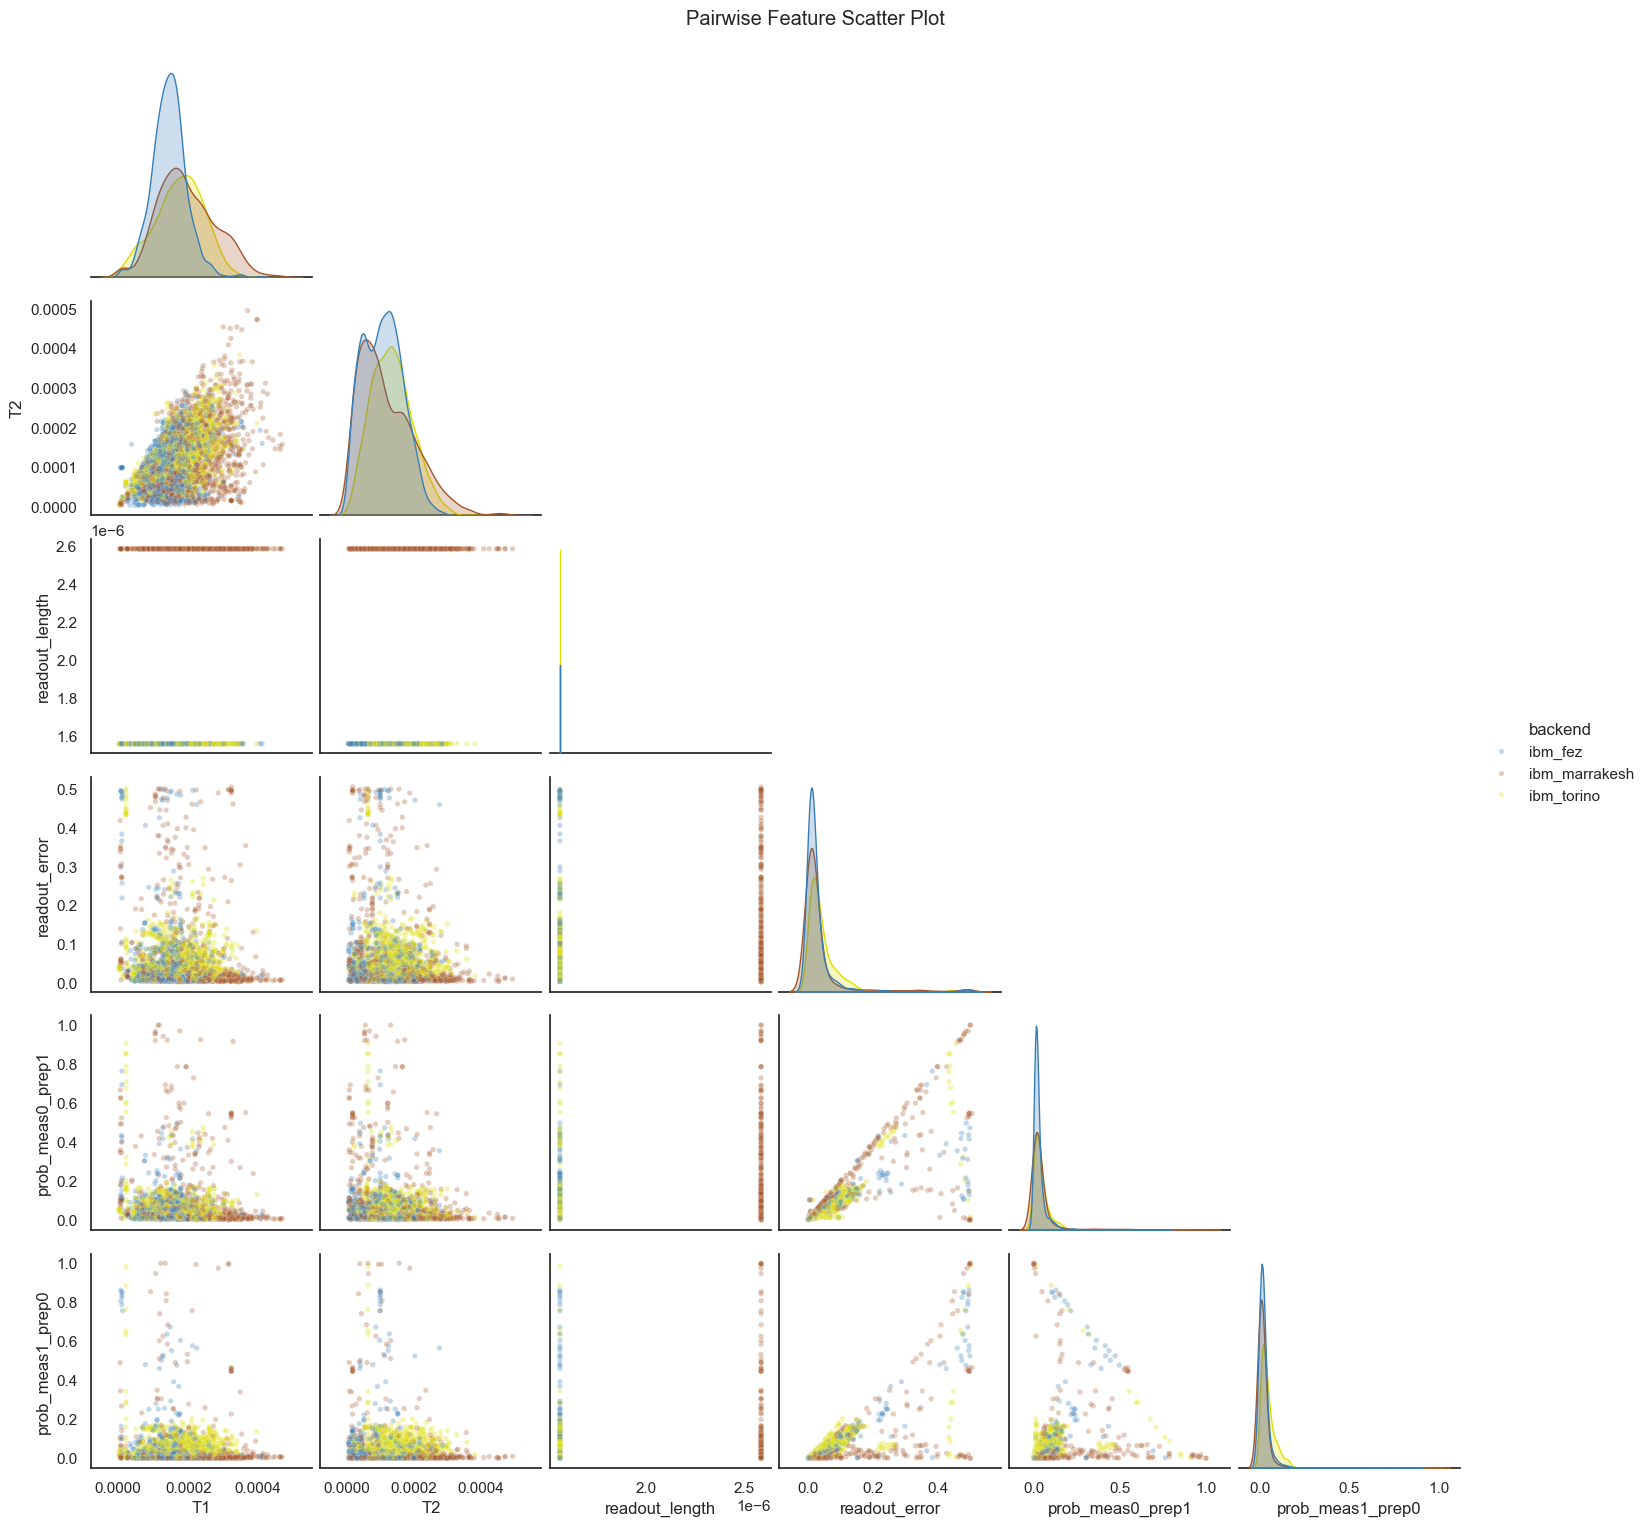

Pairplot sample size: 5000


In [101]:
import seaborn as sns

CB_color_cycle = ['#377eb8', '#a65628', '#dede00']

sns.set_palette(CB_color_cycle)

features = ["T1", "T2", "readout_length", "readout_error",
            "prob_meas0_prep1", "prob_meas1_prep0"]

df_plot = df_qubit[features + ["backend"]].dropna()
df_plot = df_plot.sample(5000, random_state=0)

sns.pairplot(
    df_plot,
    vars=features,
    hue="backend",      # optional
    corner=True,        # avoid duplicate upper triangle
    plot_kws=dict(alpha=0.3, s=15)
)

plt.suptitle("Pairwise Feature Scatter Plot", y=1.02)
plt.show()

print("Pairplot sample size:", len(df_plot))

Pairwise scatter plots reveal non-linear relationships and clustering between backends.
Subsampling is necessary for rendering performance and may hide rare regimes.


In [102]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Example: weighted aggregation per entity
metrics = ["T1", "T2", "readout_length", "readout_error", "prob_meas0_prep1", "prob_meas1_prep0"]
df_agg = df_qubit.copy().dropna()

# Optional: weighted average per entity per scrape
df_agg = df_agg.groupby("entity").apply(
    lambda g: pd.Series({
        m: np.average(g[m], weights=g["duration_sec"]) for m in metrics
    })
).reset_index()

# Scale metrics
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_agg[metrics])


C:\Users\louis\AppData\Local\Temp\ipykernel_9708\1838899230.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_agg = df_agg.groupby("entity").apply(


In [103]:
pca = PCA(n_components=2)  # first 2 principal components
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.43814319 0.25779277]


C:\Users\louis\AppData\Local\Temp\ipykernel_9708\3675292443.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10")


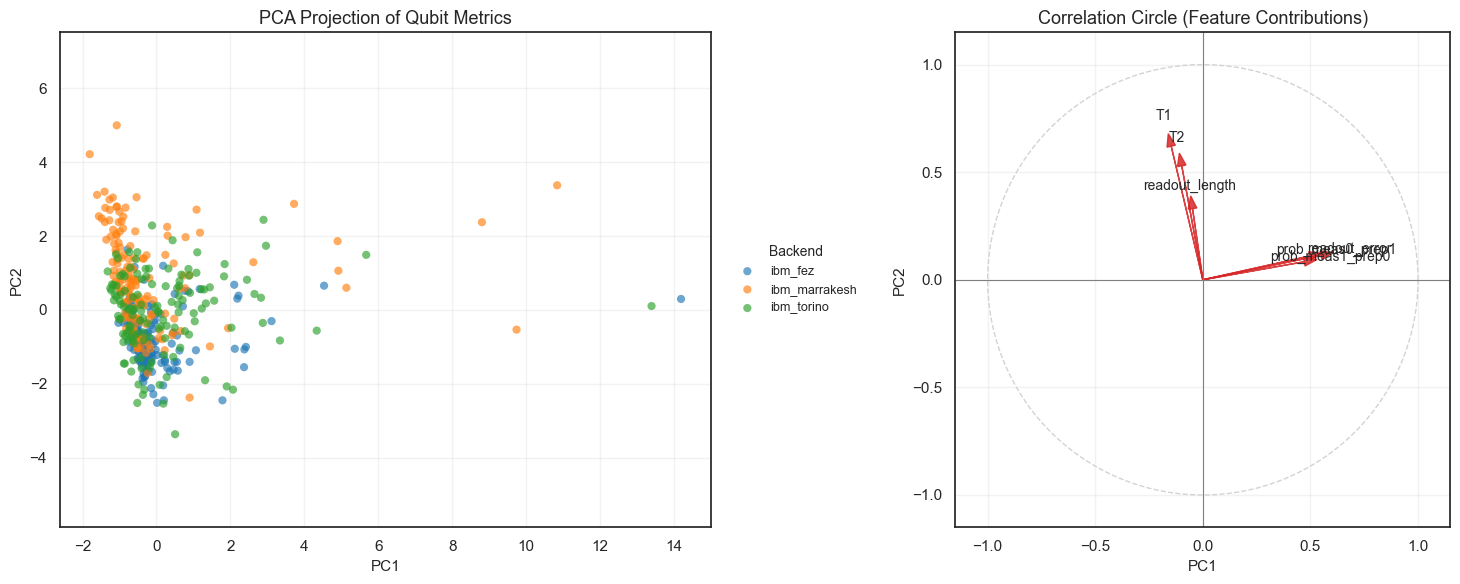

Explained variance ratio: [0.43814319 0.25779277]
Total explained variance (2 PCs): 0.6959359595680679


,PC1,PC2
T1,-0.160803,0.679193
T2,-0.109001,0.588598
readout_length,-0.056458,0.390045
readout_error,0.608349,0.126111
prob_meas0_prep1,0.554748,0.123715
prob_meas1_prep0,0.530319,0.094368


In [104]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# -------------------------
# Prepare backend labels
# -------------------------
backends = df_agg["entity"].apply(lambda x: x.split("|")[0])
unique_backends = sorted(backends.unique())

# Colorblind-friendly colormap
cmap = get_cmap("tab10")
colors = {b: cmap(i % 10) for i, b in enumerate(unique_backends)}

# -------------------------
# Figure layout
# -------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 6),
    gridspec_kw={"width_ratios": [1.2, 1]},
)

# ============================================================
# PCA SCATTER
# ============================================================
ax = axes[0]

for b in unique_backends:
    mask = backends == b
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=35,
        alpha=0.65,
        color=colors[b],
        label=b,
        edgecolors="none",
    )

ax.set_xlabel("PC1", fontsize=11)
ax.set_ylabel("PC2", fontsize=11)
ax.set_title("PCA Projection of Qubit Metrics", fontsize=13)

# Equal scaling improves geometry perception
ax.set_aspect("equal", adjustable="datalim")

ax.grid(True, alpha=0.25)

# Compact legend outside plot
ax.legend(
    title="Backend",
    fontsize=9,
    title_fontsize=10,
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)

# ============================================================
# CORRELATION CIRCLE
# ============================================================
ax = axes[1]
loadings = pca.components_.T

# Unit circle
theta = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), "--", color="lightgray", lw=1)

# Axes lines
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", lw=0.8)

# Feature arrows
for i, name in enumerate(metrics):
    x, y = loadings[i, 0], loadings[i, 1]

    ax.arrow(
        0, 0, x, y,
        color="tab:red",
        alpha=0.85,
        head_width=0.04,
        length_includes_head=True,
    )

    ax.text(
        x * 1.12,
        y * 1.12,
        name,
        fontsize=10,
        ha="center",
        va="center",
    )

ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)
ax.set_aspect("equal")

ax.set_xlabel("PC1", fontsize=11)
ax.set_ylabel("PC2", fontsize=11)
ax.set_title("Correlation Circle (Feature Contributions)", fontsize=13)

ax.grid(True, alpha=0.25)

# -------------------------
# Global layout
# -------------------------
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance (2 PCs):",
      pca.explained_variance_ratio_.sum())

loadings_df = pd.DataFrame(
    loadings,
    index=metrics,
    columns=["PC1", "PC2"]
)
display(loadings_df)

### PCA interpretation

- PC1 captures the dominant variance (~X%) and is dominated by coherence metrics (T1 and T2)
- PC2 captures secondary variation (~Y%)  and is dominated by error metrics (readout_error, prob_meas0_prep1, prob_meas1_prep0)

Interpretation example:
- Positive PC1 loading on T1/T2 suggests coherence-driven separation.
- Opposing loading between error and coherence indicates trade-offs.

Limitations:
- PCA assumes linear relationships.
- Scaling strongly influences geometry.


 ## 4. Gate-Level Analysis

In [105]:
df_gate.groupby(["backend","gate"])["entity"].nunique().groupby("backend").size()

backend
ibm_fez          10
ibm_marrakesh     9
ibm_torino        9
Name: entity, dtype: int64

<Axes: xlabel='backend'>

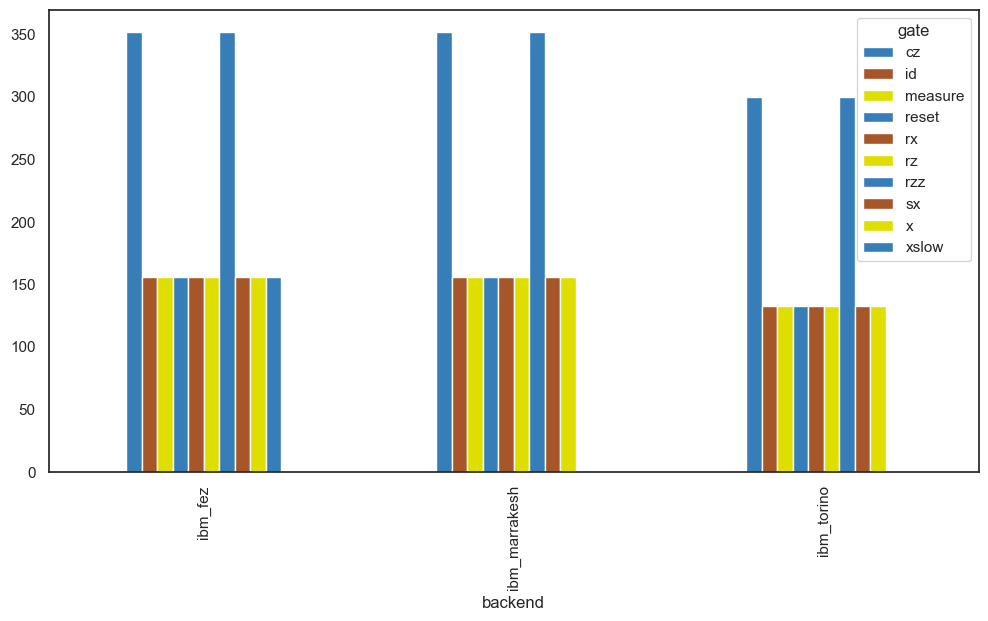

In [106]:
df_gate_counts = (
    df_gate
        .groupby(["backend", "gate"])["entity"]
        .nunique()
        .unstack(fill_value=0)
)

df_gate_counts.plot(kind="bar", figsize=(12, 6))


In [107]:
df_medians

,T1,T2,readout_length,readout_error,prob_meas0_prep1,prob_meas1_prep0
ibm_fez,0.000144,0.000102,0.000002,0.012207,0.016602,0.008057
ibm_marrakesh,0.000184,0.000100,0.000003,0.011841,0.018555,0.003662
ibm_torino,0.000180,0.000132,0.000002,0.033447,0.030029,0.032715


C:\Users\louis\AppData\Local\Temp\ipykernel_9708\877675866.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: weighted_quantile(


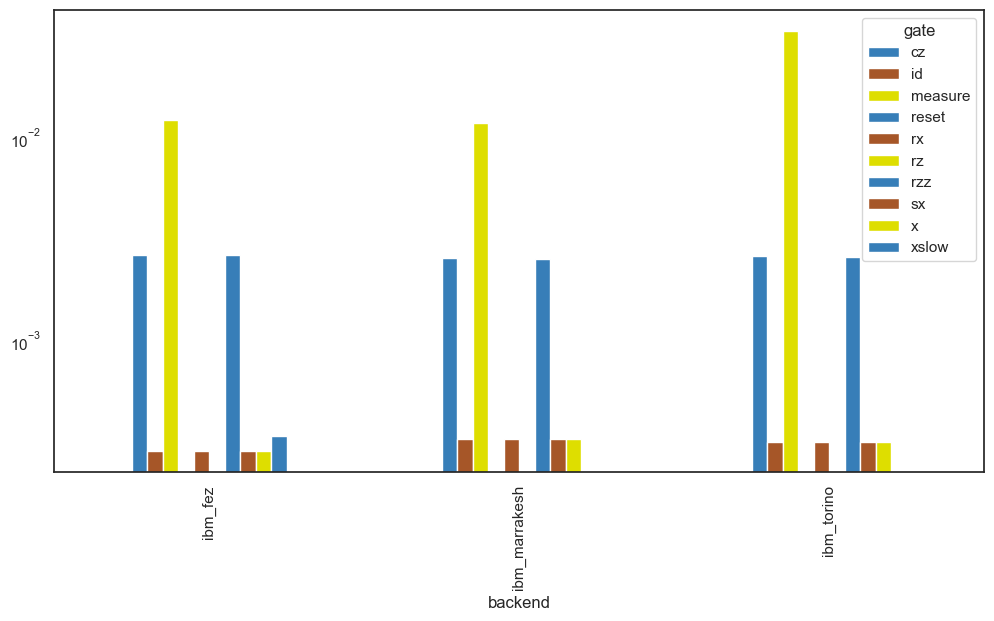

In [108]:
df_medians = (
    df_gate
        .groupby(["backend", "gate"])
        .apply(lambda g: weighted_quantile(
            g["gate_error"].to_numpy(),
            g["duration_sec"].to_numpy(),
            [0.5]
        )[0])
        .unstack()
)

df_medians.plot(kind="bar", figsize=(12, 6))
plt.yscale("log")


In [109]:
nan_mask = df_gate.isna().any(axis=1)
df_nan = df_gate[nan_mask]


In [110]:
df_gate.isna().mean().sort_values(ascending=False)


gate_error      0.000923
scrape_time     0.000000
backend         0.000000
gate            0.000000
qubits          0.000000
gate_length     0.000000
entity          0.000000
arity           0.000000
qubit           0.000000
next_time       0.000000
duration_sec    0.000000
dtype: float64

In [111]:
nan_by_backend = (
    df_gate.assign(has_nan=df_gate.isna().any(axis=1))
      .groupby("backend")["has_nan"]
      .agg(["count", "sum", "mean"])
      .sort_values("mean", ascending=False)
)
nan_by_backend 

,count,sum,mean
backend,,,
ibm_torino,138249,133,0.000962
ibm_marrakesh,166244,156,0.000938
ibm_fez,177509,156,0.000879


In [112]:
nan_by_gate = (
    df_gate.assign(has_nan=df_gate.isna().any(axis=1))
      .groupby("gate")["has_nan"]
      .agg(["count", "sum", "mean"])
      .sort_values("mean", ascending=False)
)

nan_by_gate

,count,sum,mean
gate,,,
reset,445,445,1.0
cz,70070,0,0.0
id,32626,0,0.0
measure,198203,0,0.0
rx,32626,0,0.0
rz,445,0,0.0
rzz,82024,0,0.0
sx,32626,0,0.0
x,32626,0,0.0


C:\Users\louis\AppData\Local\Temp\ipykernel_9708\3687453429.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: weighted_quantile(
C:\Users\louis\AppData\Local\Temp\ipykernel_9708\3687453429.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: weighted_quantile(


NameError: name 'gate_categories' is not defined

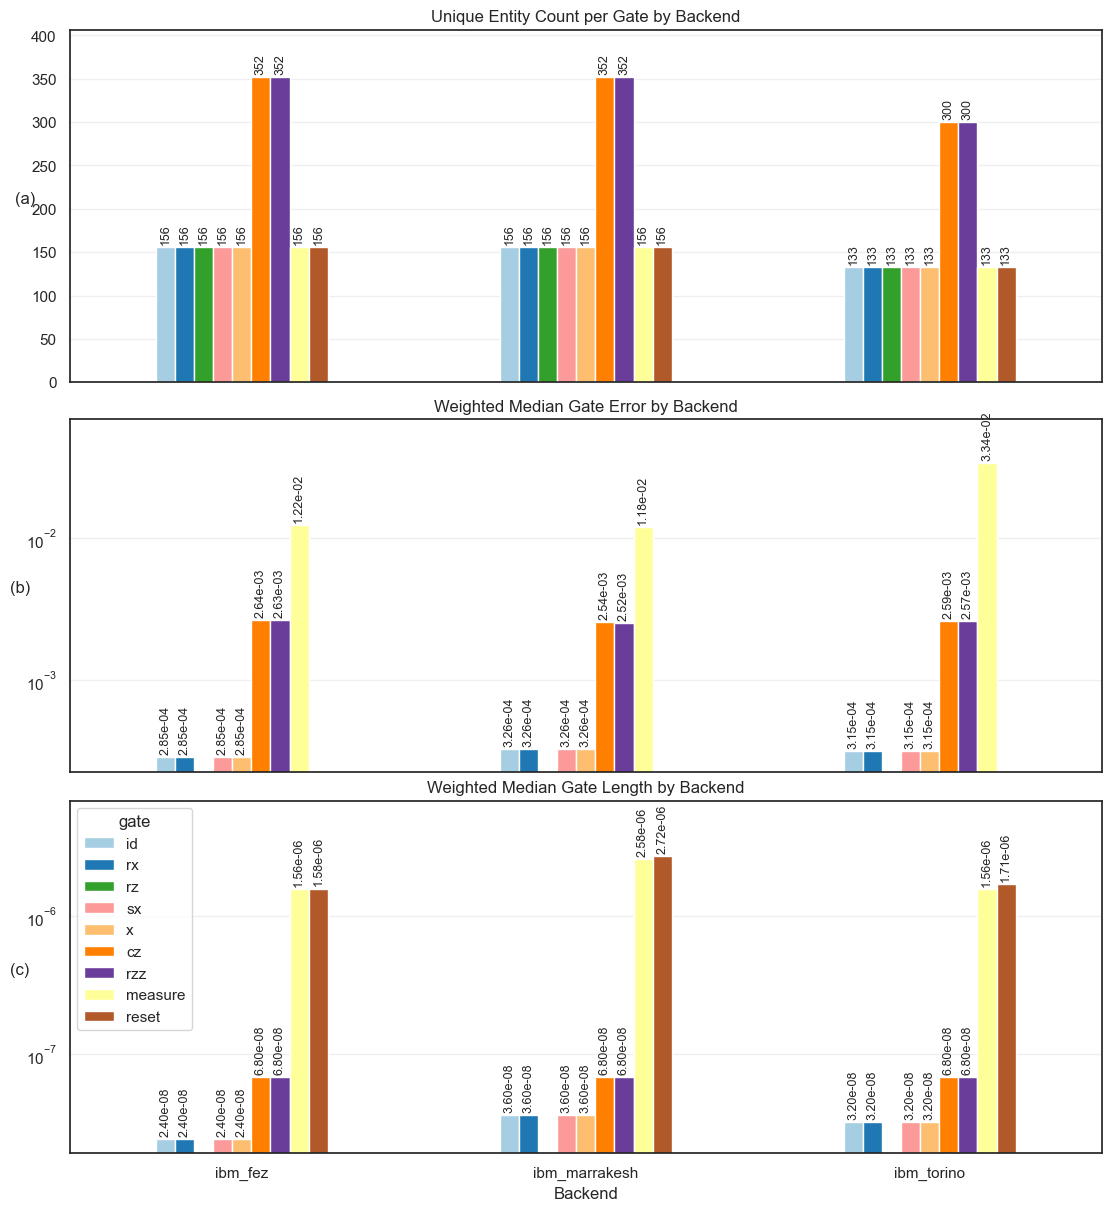

In [113]:
df_gate_counts = (
    df_gate
        .groupby(["backend", "gate"])["entity"]
        .nunique()
        .unstack(fill_value=0)
)
df_gate_counts =  df_gate_counts[["id", "rx", "rz", "sx", "x", "cz", "rzz", "measure", "reset"]]

df_median_error = (
    df_gate
        .groupby(["backend", "gate"])
        .apply(lambda g: weighted_quantile(
            g["gate_error"].to_numpy(),
            g["duration_sec"].to_numpy(),
            [0.5]
        )[0])
        .unstack()
)
df_median_error =  df_median_error[["id", "rx", "rz", "sx", "x", "cz", "rzz", "measure", "reset"]]

df_median_length = (
    df_gate
        .groupby(["backend", "gate"])
        .apply(lambda g: weighted_quantile(
            g["gate_length"].to_numpy(),
            g["duration_sec"].to_numpy(),
            [0.5]
        )[0])
        .unstack()
)
df_median_length =  df_median_length[["id", "rx", "rz", "sx", "x", "cz", "rzz", "measure", "reset"]]


def add_headroom(ax, factor=1.15):
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * factor)


def label_bars(ax, fmt="{:.2g}", min_height=0):
    for container in ax.containers:
        for bar in container:
            h = bar.get_height()
            if h <= min_height or not np.isfinite(h):
                continue
            ax.annotate(
                fmt.format(h),
                (bar.get_x() + bar.get_width() / 2, h),
                ha="center",
                va="bottom",
                fontsize=9,
                rotation=90,
                xytext=(0, 2),
                textcoords="offset points"
            )

fig, axes = plt.subplots(
    3, 1,
    figsize=(11, 12),
    sharex=True,
    constrained_layout=True
)

colormap="Paired"


gate_counts = df_gate_counts.plot(kind="bar", ax=axes[0], legend=False, colormap=colormap)
axes[0].set_title("Unique Entity Count per Gate by Backend")
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].set_ylabel("(a)", rotation=0)
label_bars(axes[0], fmt="{:.0f}")   # integer counts
add_headroom(axes[0],1.1)



median_error = df_median_error.plot(kind="bar", ax=axes[1] , legend = False, colormap=colormap)
axes[1].set_yscale("log")
axes[1].set_title("Weighted Median Gate Error by Backend")
axes[1].grid(True, axis="y", alpha=0.3)
axes[1].set_ylabel("(b)", rotation=0)
label_bars(axes[1], fmt="{:.2e}")   # scientific format
add_headroom(axes[1],1.6)


median_length = df_median_length.plot(kind="bar", ax=axes[2], colormap=colormap)
axes[2].set_yscale("log")
axes[2].set_title("Weighted Median Gate Length by Backend")
axes[2].grid(True, axis="y", alpha=0.3)
axes[2].set_ylabel("(c)", rotation=0)
label_bars(axes[2], fmt="{:.2e}")   # scientific format
add_headroom(axes[2],2)

axes[-1].tick_params(axis="x", rotation=0)
axes[-1].set_xlabel("Backend")

# Map x positions to gate categories
x_positions = np.arange(len(df_gate_counts.columns))
category_series = pd.Series([gate_categories[g] for g in df_gate_counts.columns], index=df_gate_counts.columns)

# Find boundary positions where category changes
boundaries = np.where(category_series.values[:-1] != category_series.values[1:])[0]

for ax in axes:
    for b in boundaries:
        ax.axvline(b + 0.5, color="black", linestyle="--", alpha=0.5)


plt.tight_layout()

plt.show()


In [ ]:
gate_categories

{'cz': '2Q',
 'id': '1Q',
 'measure': 'non-op',
 'reset': 'non-op',
 'rx': '1Q',
 'rz': '1Q',
 'rzz': '2Q',
 'sx': '1Q',
 'x': '1Q'}

In [114]:
# Example mapping, adjust to your gates
one_qubit_gates = ["id", "rx", "rz", "sx", "x", "cz", "rzz", "measure", "reset"]
two_qubit_gates = ["cz", "rzz"]
non_op_gates = ["measure", "reset"]

gate_categories = {}
for g in df_gate_counts.columns:
    if g in one_qubit_gates:
        gate_categories[g] = "1Q"
    elif g in two_qubit_gates:
        gate_categories[g] = "2Q"
    else:
        gate_categories[g] = "non-op"

In [115]:
print("Gate Counts, Median Error, Median Length DataFrames:")
print(df_gate_counts)
print(df_median_error)
print(df_median_length)

Gate Counts, Median Error, Median Length DataFrames:
gate            id   rx   rz   sx    x   cz  rzz  measure  reset
backend                                                         
ibm_fez        156  156  156  156  156  352  352      156    156
ibm_marrakesh  156  156  156  156  156  352  352      156    156
ibm_torino     133  133  133  133  133  300  300      133    133
gate                 id        rx   rz        sx         x        cz  \
backend                                                                
ibm_fez        0.000285  0.000285  0.0  0.000285  0.000285  0.002638   
ibm_marrakesh  0.000326  0.000326  0.0  0.000326  0.000326  0.002539   
ibm_torino     0.000315  0.000315  0.0  0.000315  0.000315  0.002588   

gate                rzz   measure  reset  
backend                                   
ibm_fez        0.002631  0.012207    NaN  
ibm_marrakesh  0.002521  0.011841    NaN  
ibm_torino     0.002571  0.033447    NaN  
gate                     id            rx   rz

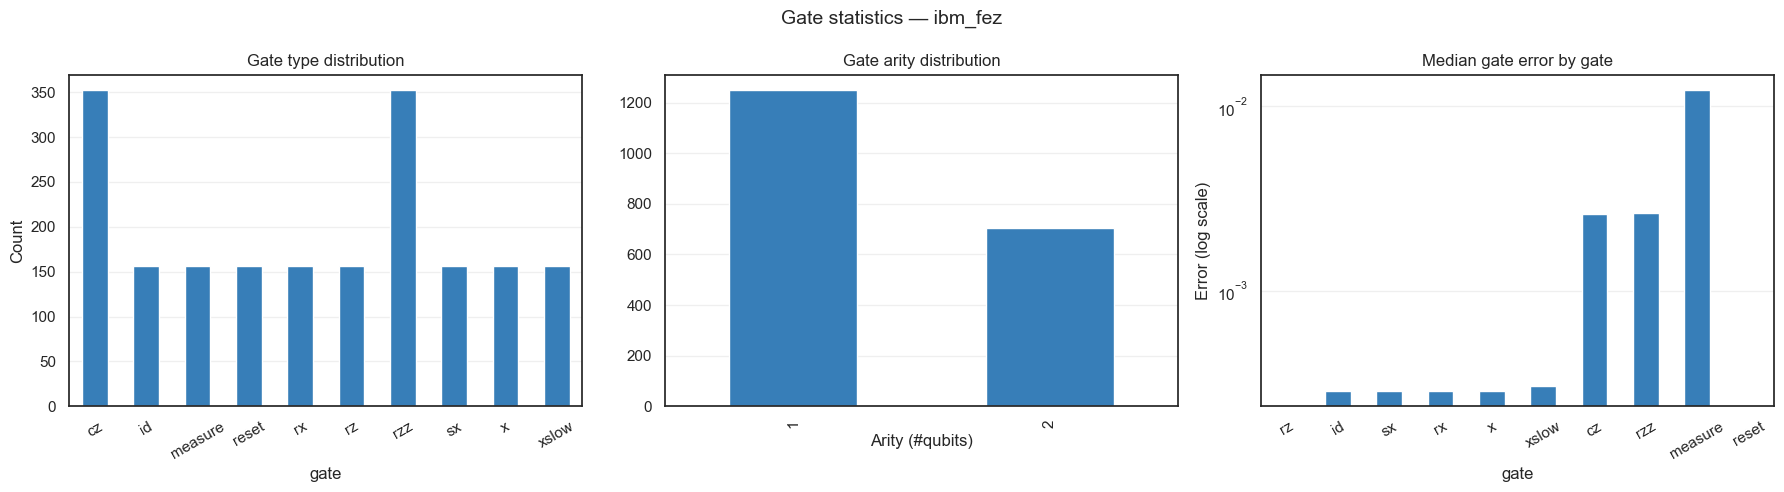

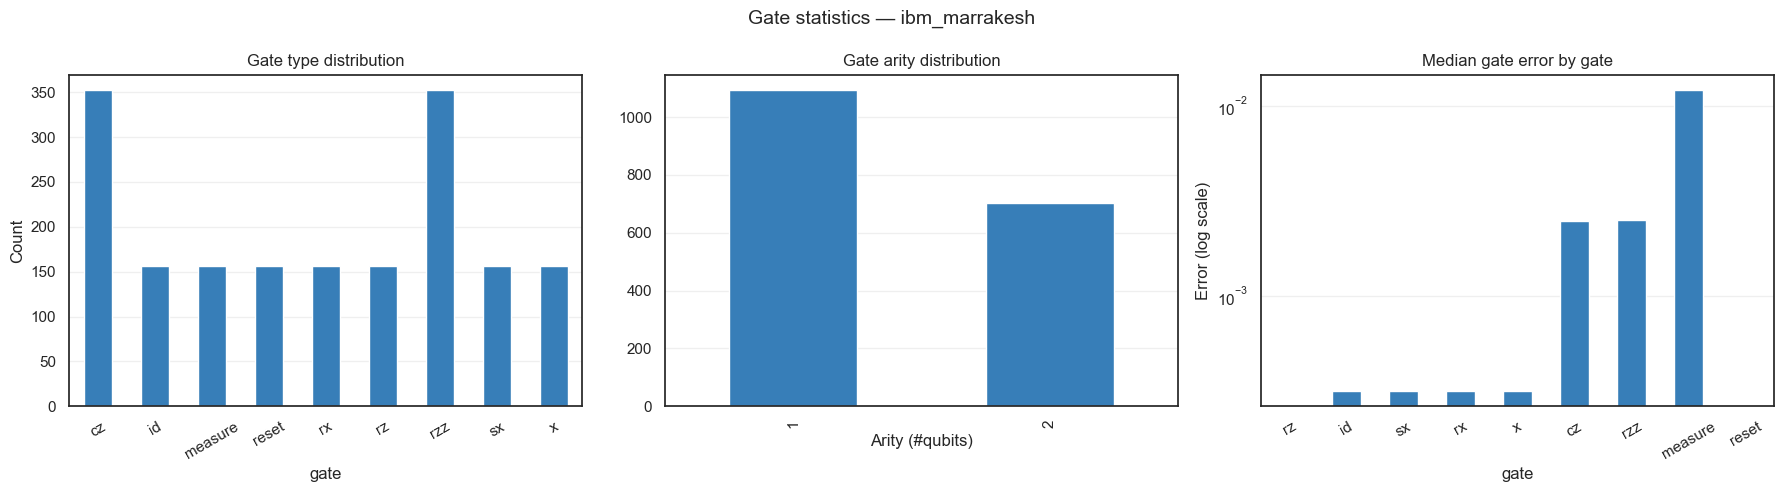

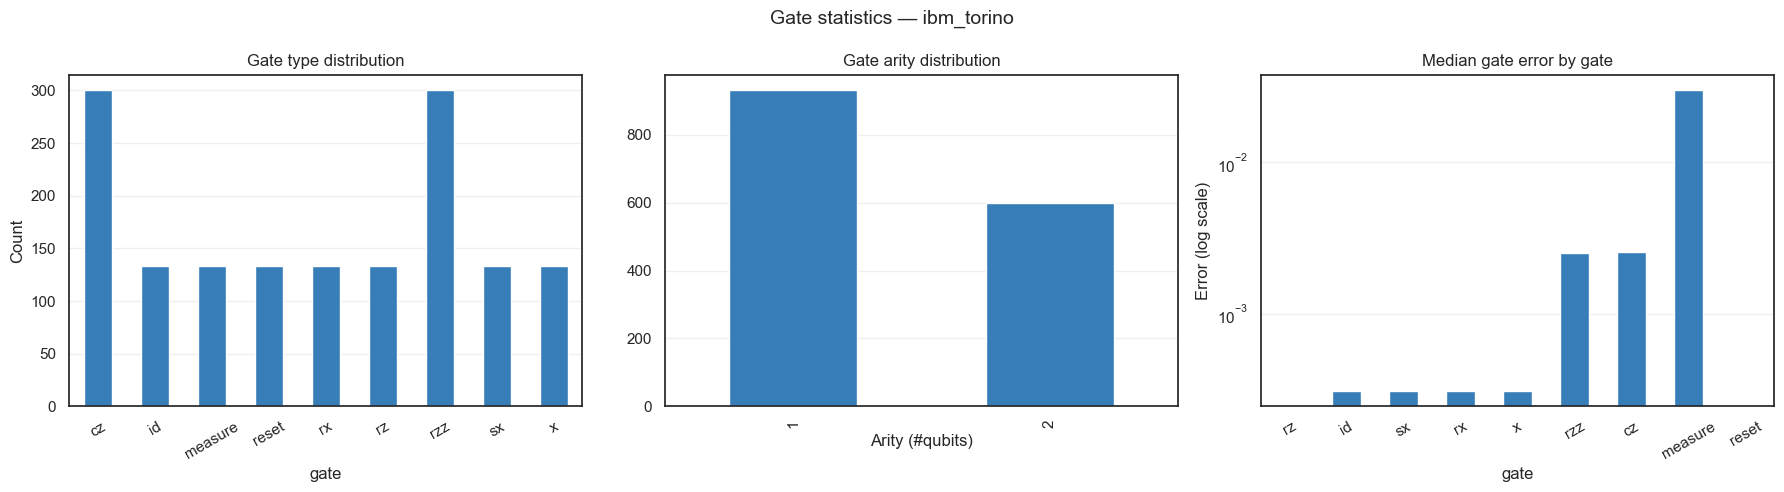

In [116]:
import matplotlib.pyplot as plt

backends = sorted(df_gate["backend"].unique())

for backend in backends:
    df_b = df_gate[df_gate["backend"] == backend]

    gate_counts = df_b.groupby("gate")["entity"].nunique()
    arity_counts = df_b.groupby("arity")["entity"].nunique()
    median_gate_error = df_b.groupby("gate")["gate_error"].median().sort_values()

    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    fig.suptitle(f"Gate statistics — {backend}", fontsize=14)

    # --- Gate type distribution ---
    gate_counts.plot(kind="bar", ax=axes[0])
    axes[0].set_title("Gate type distribution")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].grid(axis="y", alpha=0.3)

    # --- Arity distribution ---
    arity_counts.plot(kind="bar", ax=axes[1])
    axes[1].set_title("Gate arity distribution")
    axes[1].set_xlabel("Arity (#qubits)")
    axes[1].grid(axis="y", alpha=0.3)

    # --- Median gate error ---
    median_gate_error.plot(kind="bar", ax=axes[2])
    axes[2].set_yscale("log")
    axes[2].set_title("Median gate error by gate")
    axes[2].set_ylabel("Error (log scale)")
    axes[2].tick_params(axis="x", rotation=30)
    axes[2].grid(axis="y", alpha=0.3)

    plt.tight_layout()




    plt.show()


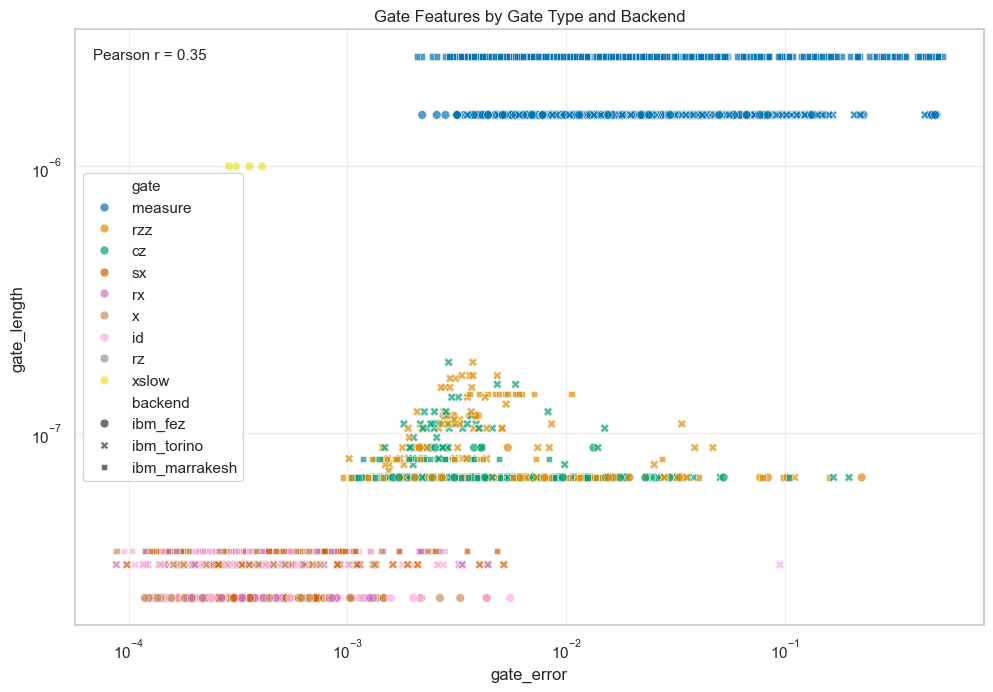

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="colorblind")

x_feature = "gate_error"
y_feature = "gate_length"   # or whatever your second feature is

df_plot = df_gate[[x_feature, y_feature, "gate", "backend"]].dropna()
df_plot = df_plot.sample(5000, random_state=0)


plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_plot,
    x=x_feature,
    y=y_feature,
    hue="gate",        # color by gate type
    style="backend",   # marker by backend
    s=40,
    alpha=0.7
)

corr_val = df_plot[[x_feature, y_feature]].corr().iloc[0,1]
plt.text(
    0.02, 0.95,
    f"Pearson r = {corr_val:.2f}",
    transform=plt.gca().transAxes,
    fontsize=11
)


plt.title("Gate Features by Gate Type and Backend")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.yscale("log")
plt.xscale("log")
plt.show()


Scatter plots visualize performance trade-offs between gate duration and error.

Weak correlations indicate that speed optimization does not always degrade fidelity directly.


 ## 5. Correlation between Qubit Metrics and 1-Qubit Gate Errors

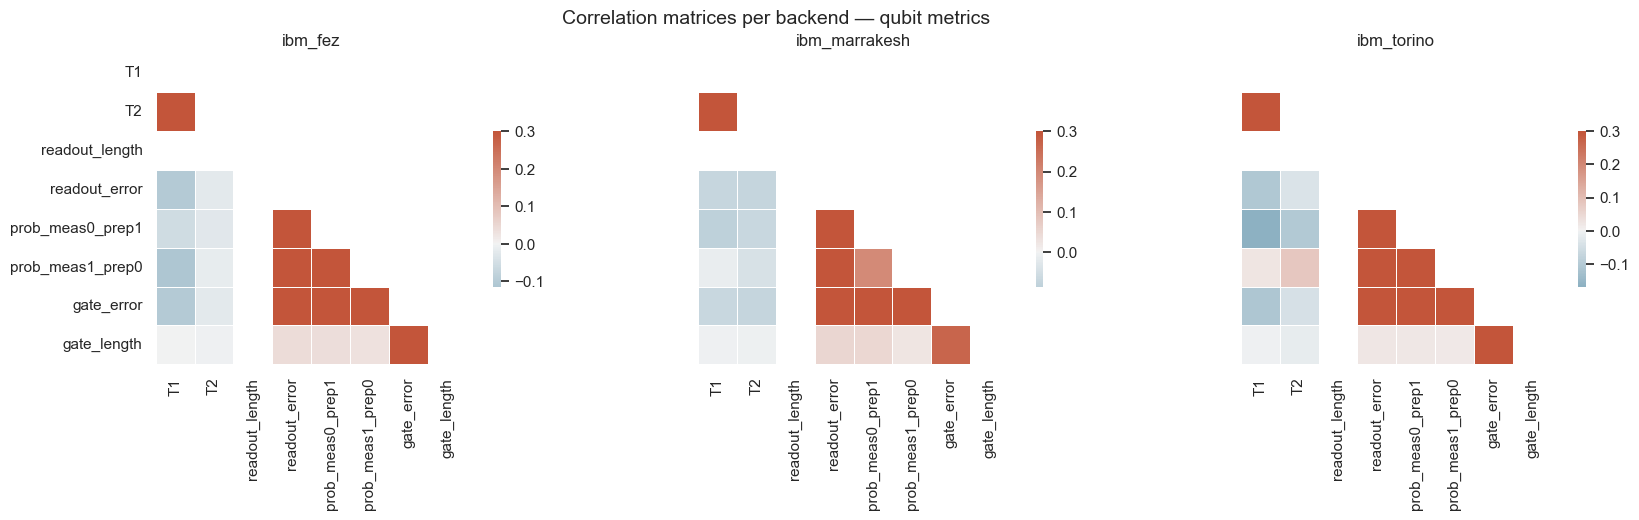

In [118]:
import seaborn as sns
import numpy as np

df_1q = df_gate[df_gate['arity']==1].merge(
    df_qubit,
    on=["backend","scrape_time","qubit"],
    how="left",
    suffixes=("_gate","_qubit")
)

metrics = ["T1", "T2", 'readout_length', "readout_error", "prob_meas0_prep1", "prob_meas1_prep0", "gate_error", "gate_length"]

sns.set_theme(style="white")

backends = sorted(df_1q["backend"].unique())
n = len(backends)

fig, axes = plt.subplots(1, n, figsize=(6*n, 5), sharey=True)

if n == 1:
    axes = [axes]

for ax, backend in zip(axes, backends):
    tmp = df_1q[df_1q["backend"] == backend][metrics]
    corr = tmp.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    cmap = sns.diverging_palette(230, 20, as_cmap=True)

    sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=ax)
    ax.set_title(f"{backend}")

fig.suptitle("Correlation matrices per backend — qubit metrics", fontsize=14)

plt.tight_layout()
plt.show()


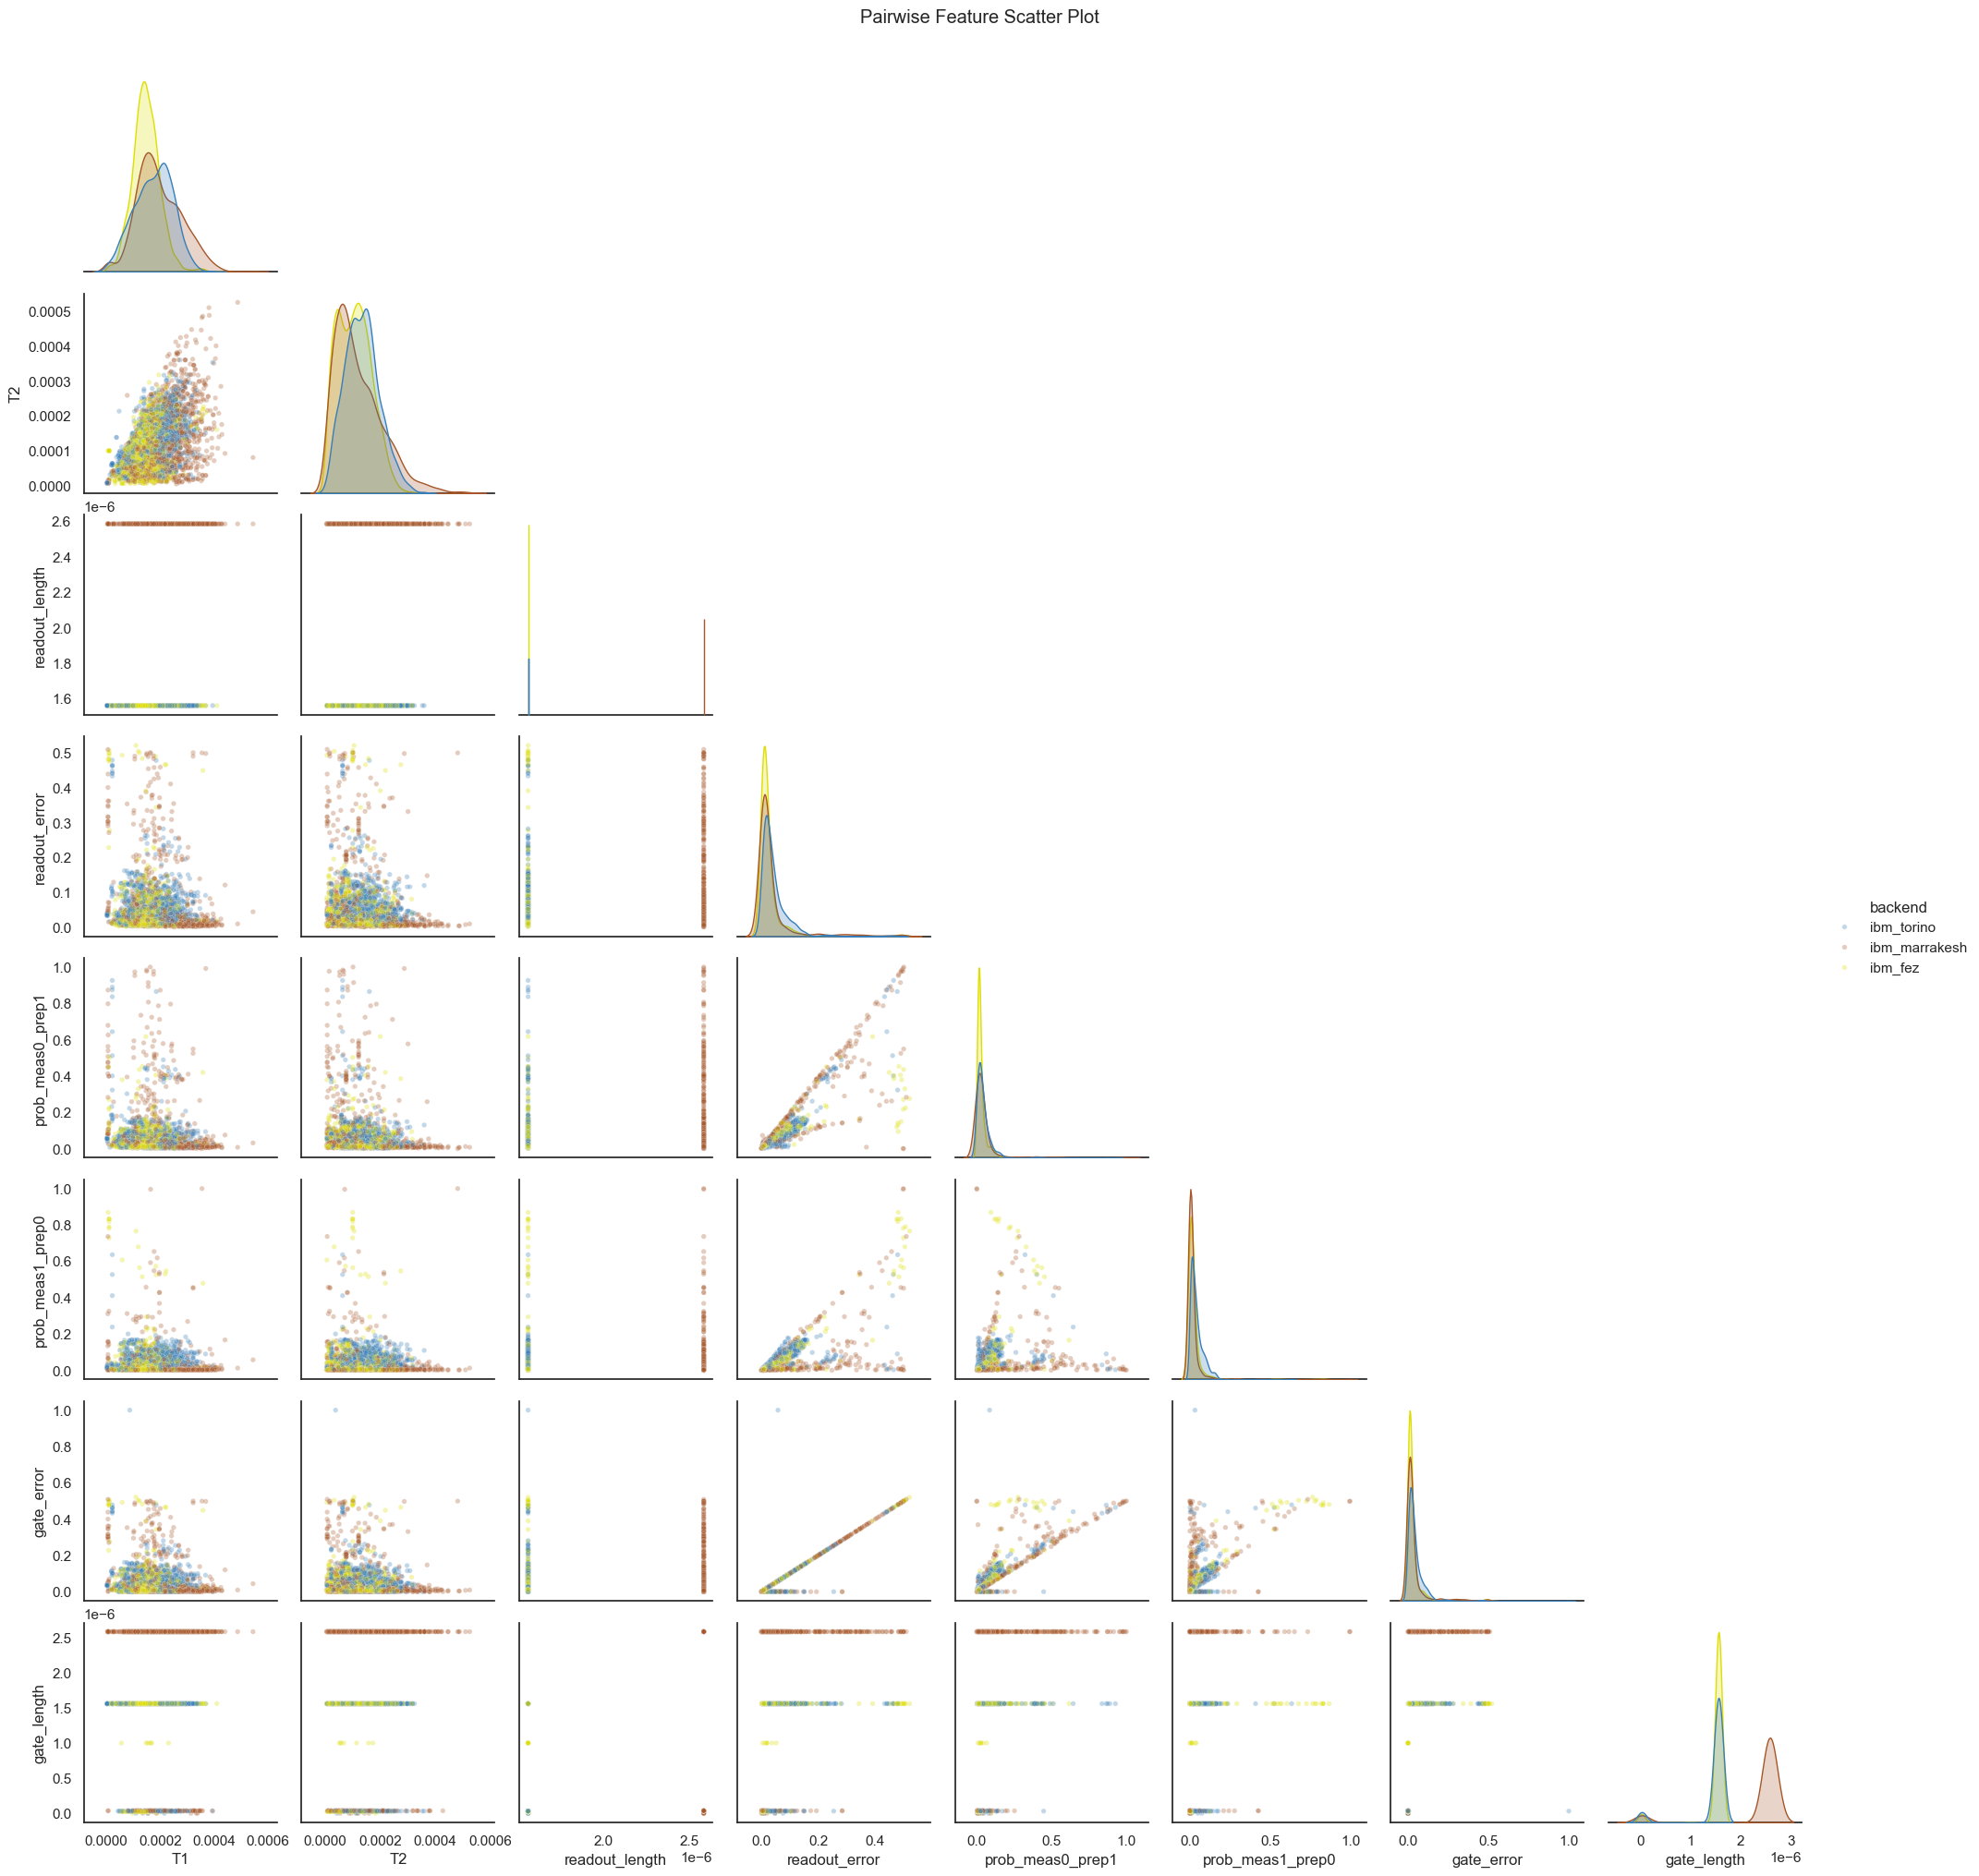

Pairplot sample size: 5000


In [119]:
import seaborn as sns

CB_color_cycle = ['#377eb8', '#a65628', '#dede00']

sns.set_palette(CB_color_cycle)

features = ["T1", "T2", "readout_length", "readout_error",
            "prob_meas0_prep1", "prob_meas1_prep0", "gate_error", "gate_length"]

df_1q = df_1q[features + ["backend"]].dropna()
df_1q = df_1q.sample(5000, random_state=0)

sns.pairplot(
    df_1q,
    vars=features,
    hue="backend",      # optional
    corner=True,        # avoid duplicate upper triangle
    plot_kws=dict(alpha=0.3, s=15)
)

plt.suptitle("Pairwise Feature Scatter Plot", y=1.02)
plt.show()

print("Pairplot sample size:", len(df_1q))

 ## 6. Temporal Trends

ibm_fez T1 drift ratio: 1.0118113114100078
ibm_marrakesh T1 drift ratio: 0.9869977873290634
ibm_torino T1 drift ratio: 0.7452292446683729


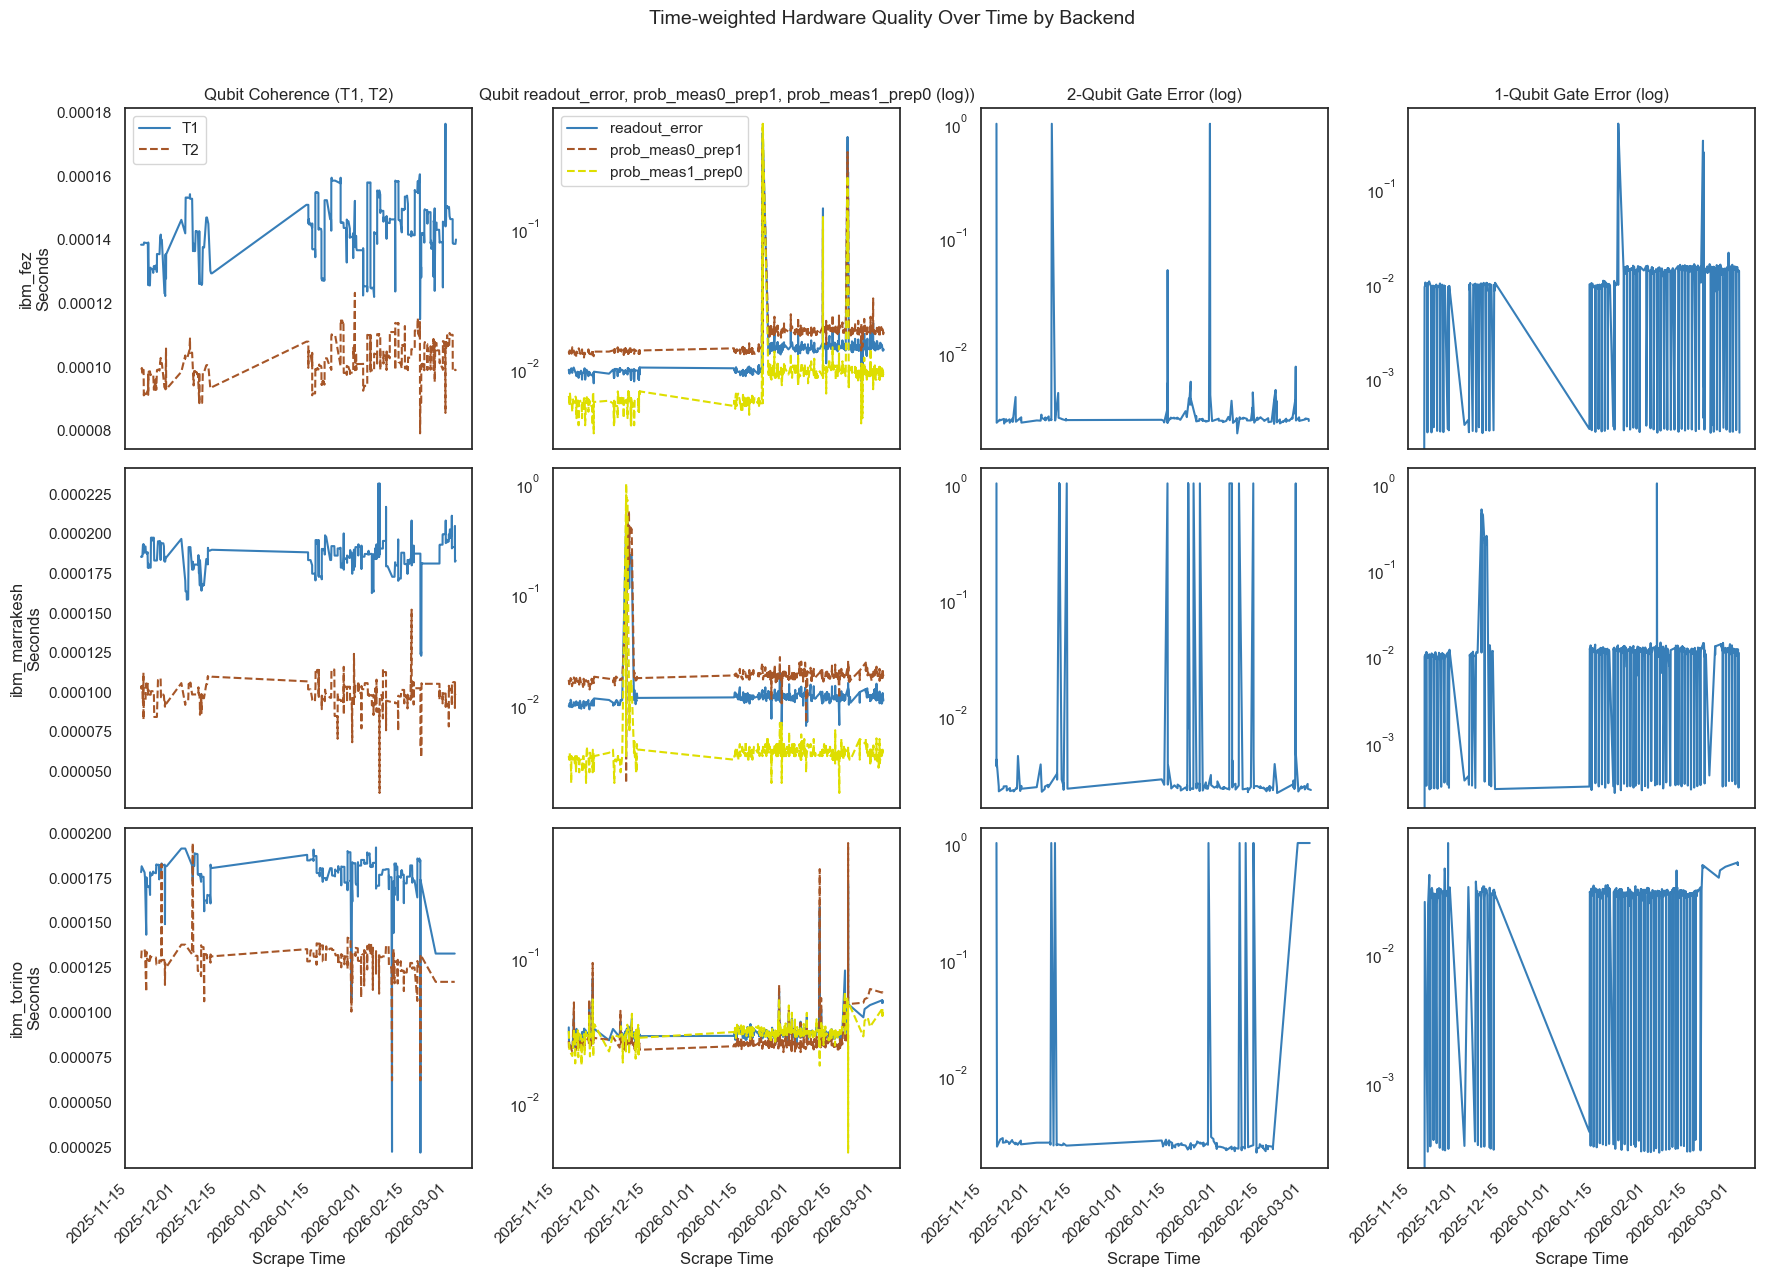

In [129]:
def weighted_median(df, value_col, weight_col="duration_sec"):
    return weighted_quantile(df[value_col], df[weight_col], [0.5])[0]

# ---------------- Plot ----------------
backends = sorted(df_qubit["backend"].unique())
n = len(backends)

fig, axes = plt.subplots(n, 4, figsize=(18, 4*n), sharex=True)

if n == 1:
    axes = axes.reshape(1, -1)

for i, backend in enumerate(backends):
    # ---------------- Column 1: T1 & T2 ----------------
    tmp_q = df_qubit[df_qubit["backend"] == backend]

    # compute weighted median per scrape_time
    med_list = []
    for scrape_time, group in tmp_q.groupby("scrape_time"):
        med_list.append({
            "scrape_time": scrape_time,
            "T1": weighted_median(group, "T1"),
            "T2": weighted_median(group, "T2")
        })
    med_q = pd.DataFrame(med_list).sort_values("scrape_time").set_index("scrape_time")
    delta_T1 = med_q["T1"].iloc[-1] / med_q["T1"].iloc[0]
    print(f"{backend} T1 drift ratio:", delta_T1)


    axes[i, 0].plot(med_q.index, med_q["T1"], label="T1")
    axes[i, 0].plot(med_q.index, med_q["T2"], linestyle="--", label="T2")
    axes[i, 0].set_ylabel(f"{backend}\nSeconds")
    if i == 0:
        axes[i, 0].set_title("Qubit Coherence (T1, T2)")
        axes[i, 0].legend()
    if i == n - 1:
        axes[i, 0].set_xlabel("Scrape Time")
    
    # ---------------- Column 1: readout_error, prob_meas0_prep1, prob_meas1_prep0 ----------------
    tmp_q = df_qubit[df_qubit["backend"] == backend]

    # compute weighted median per scrape_time
    med_list = []
    for scrape_time, group in tmp_q.groupby("scrape_time"):
        med_list.append({
            "scrape_time": scrape_time,
            "readout_error": weighted_median(group, "readout_error"),
            "prob_meas0_prep1": weighted_median(group, "prob_meas0_prep1"),
            "prob_meas1_prep0": weighted_median(group, "prob_meas1_prep0")
        })
    med_q = pd.DataFrame(med_list).sort_values("scrape_time").set_index("scrape_time")

    axes[i, 1].plot(med_q.index, med_q["readout_error"], label="readout_error")
    axes[i, 1].plot(med_q.index, med_q["prob_meas0_prep1"], linestyle="--", label="prob_meas0_prep1")
    axes[i, 1].plot(med_q.index, med_q["prob_meas1_prep0"], linestyle="--", label="prob_meas1_prep0")
    axes[i, 1].set_yscale("log")
    if i == 0:
        axes[i, 1].set_title("Qubit readout_error, prob_meas0_prep1, prob_meas1_prep0 (log))")
        axes[i, 1].legend()
    if i == n - 1:
        axes[i, 1].set_xlabel("Scrape Time")

    # ---------------- Column 2: 1Q gate error ----------------
    tmp_g1 = df_gate[(df_gate["backend"] == backend) & (df_gate["arity"] == 1)]
    med_list_g1 = []
    for scrape_time, group in tmp_g1.groupby("scrape_time"):
        med_list_g1.append({
            "scrape_time": scrape_time,
            "gate_error": weighted_median(group, "gate_error")
        })
    med_g1 = pd.DataFrame(med_list_g1).sort_values("scrape_time").set_index("scrape_time")

    axes[i, 3].plot(med_g1.index, med_g1["gate_error"].values)
    axes[i, 3].set_yscale("log")
    if i == 0:
        axes[i, 3].set_title("1-Qubit Gate Error (log)")
    if i == n - 1:
        axes[i, 3].set_xlabel("Scrape Time")

    # ---------------- Column 3: 2Q gate error ----------------
    tmp_g2 = df_gate[(df_gate["backend"] == backend) & (df_gate["arity"] == 2)]
    med_list_g2 = []
    for scrape_time, group in tmp_g2.groupby("scrape_time"):
        med_list_g2.append({
            "scrape_time": scrape_time,
            "gate_error": weighted_median(group, "gate_error")
        })
    med_g2 = pd.DataFrame(med_list_g2).sort_values("scrape_time").set_index("scrape_time")

    axes[i, 2].plot(med_g2.index, med_g2["gate_error"].values)
    axes[i, 2].set_yscale("log")
    if i == 0:
        axes[i, 2].set_title("2-Qubit Gate Error (log)")
    if i == n - 1:
        axes[i, 2].set_xlabel("Scrape Time")

fig.suptitle("Time-weighted Hardware Quality Over Time by Backend", y=1.02, fontsize=14)
plt.tight_layout()
for ax in axes[-1, :]:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")
plt.show()

Temporal trends reveal calibration drift and maintenance effects.

Stable backends exhibit slow monotonic drift.
Abrupt changes may indicate recalibration or hardware intervention.


 ## 7. Update frequency analysis

In [121]:
from matplotlib.ticker import LogLocator, FuncFormatter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
import pandas as pd

def hours_formatter(y, _):
    """
    Format hours into readable units automatically.
    """
    if y < 1:
        return f"{int(y*60)}m"
    elif y < 24:
        return f"{y:.0f}h"
    else:
        return f"{y/24:.0f}d"

c:\Users\louis\Documents\M2\Quantum-error-prediction\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\louis\Documents\M2\Quantum-error-prediction\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


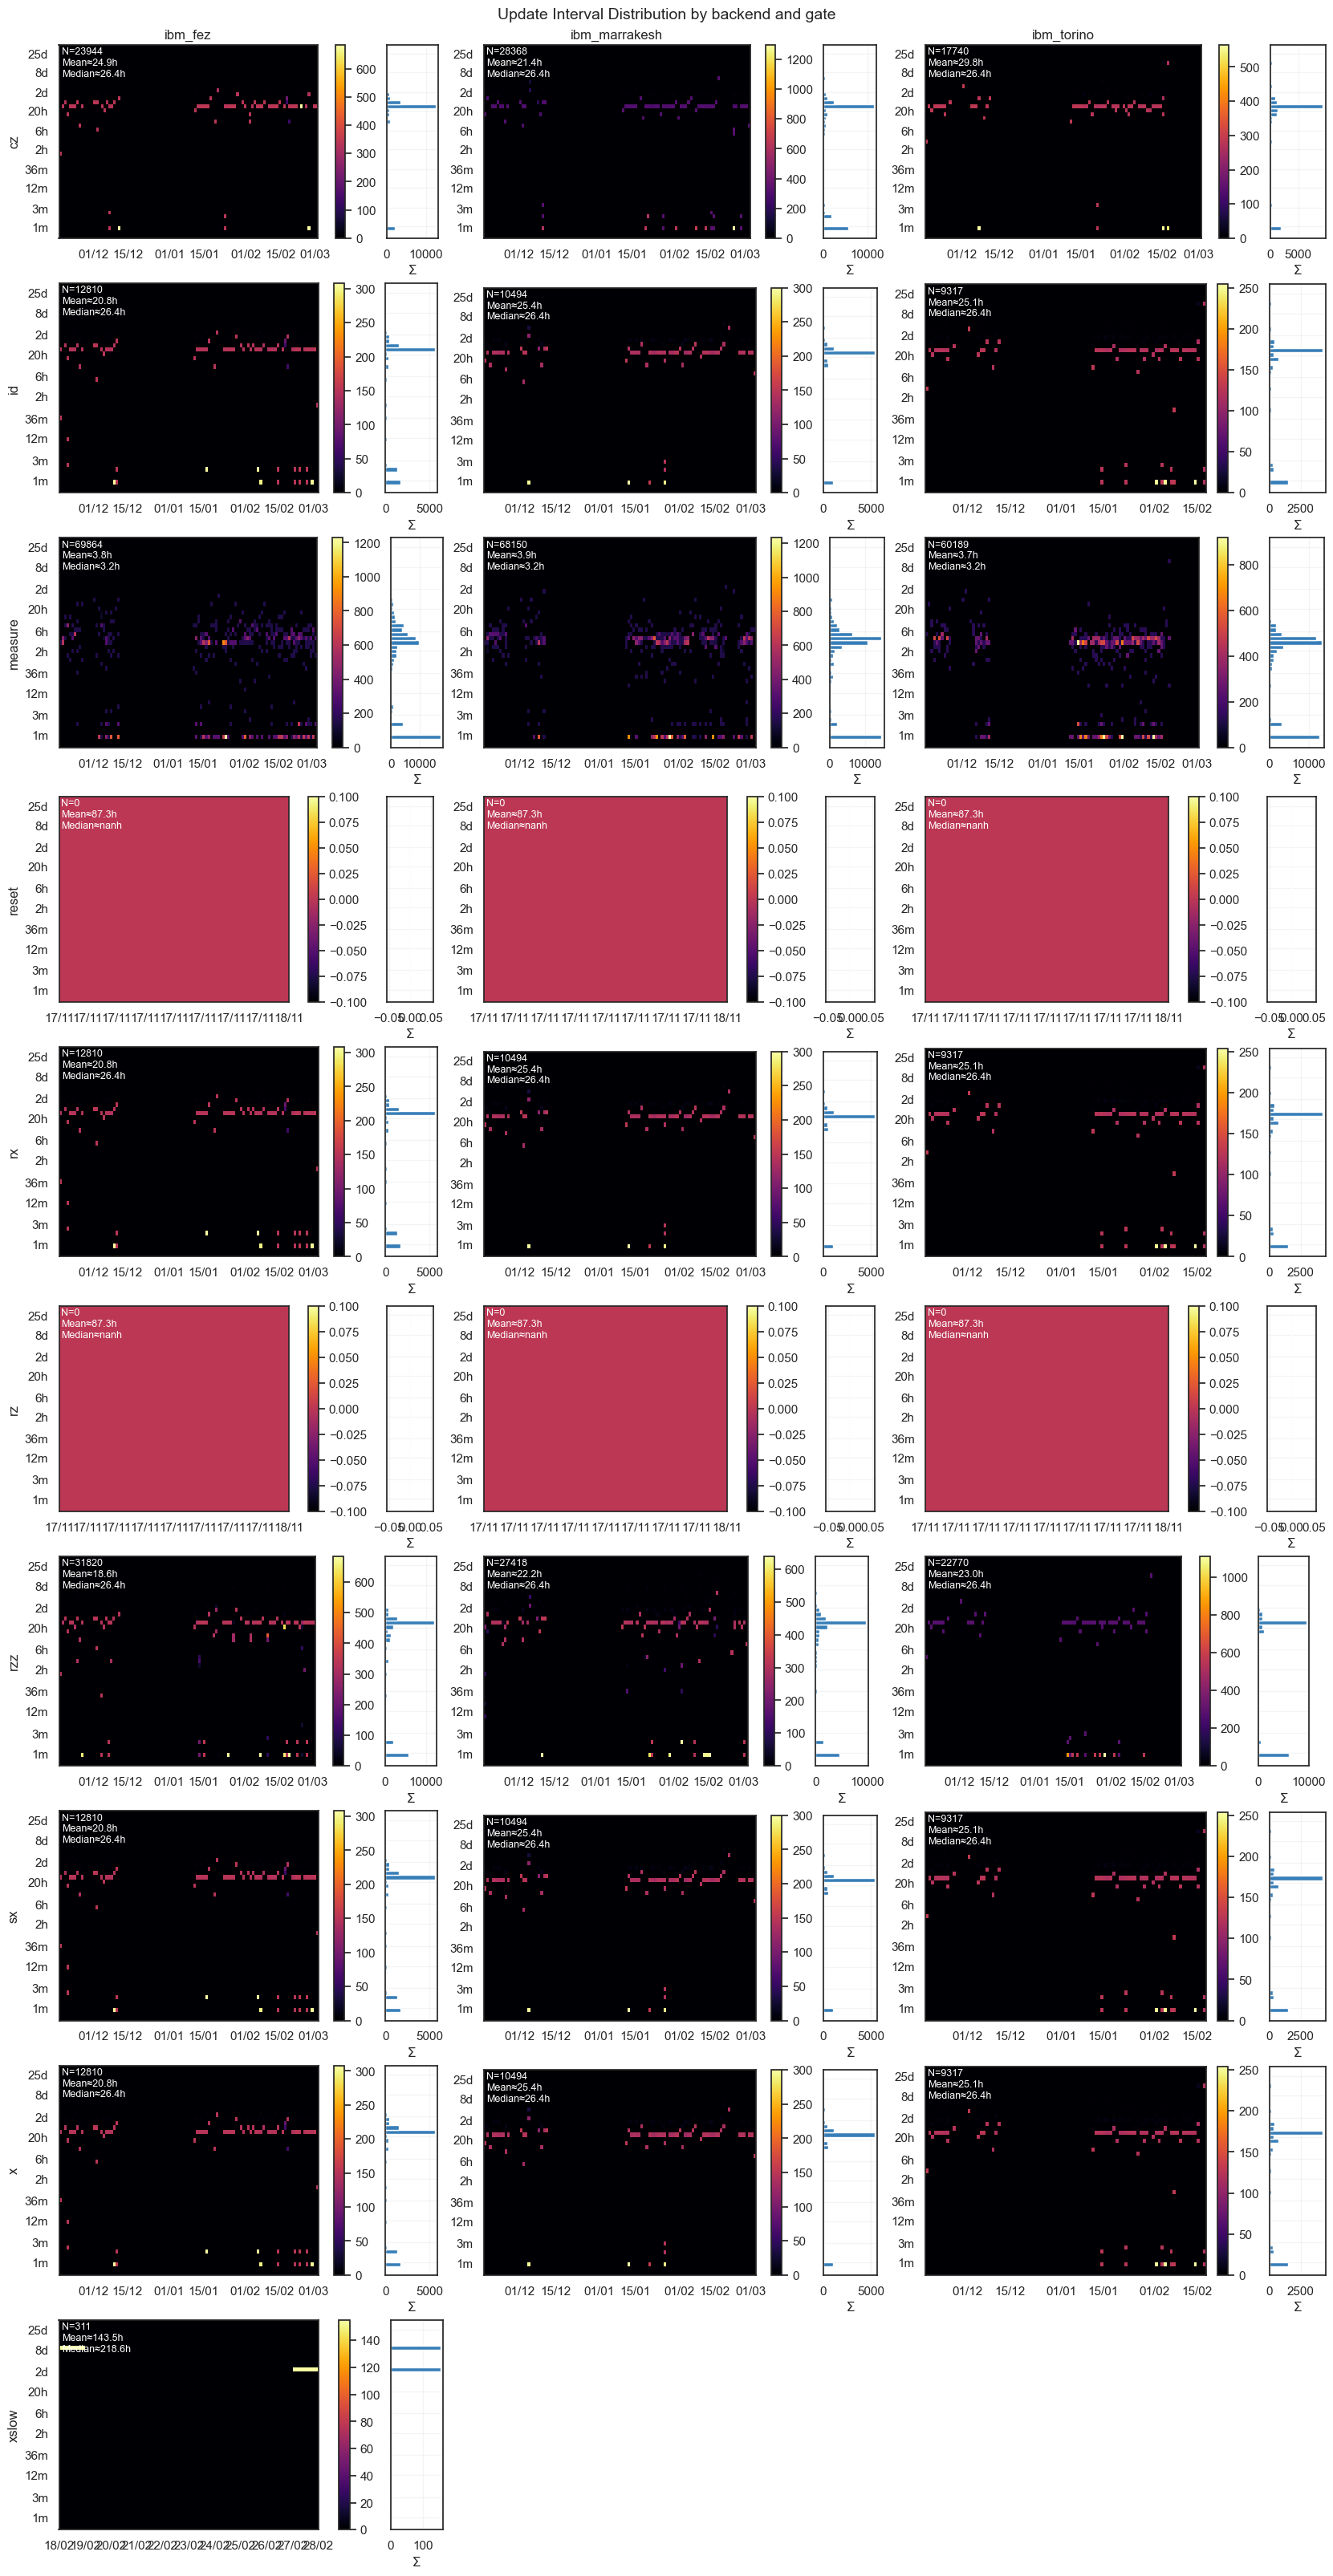

In [122]:
from matplotlib.ticker import LogLocator, FuncFormatter
from matplotlib.gridspec import GridSpecFromSubplotSpec

def plot_calibration_update_heatmaps(
    df_data,
    hour_min=0.01,
    hour_max=1000,
    n_bins=50,
    time_bin="1d",
    log_scale=True,
    log_count=False,
    group_by_1=None,
    group_by_2=None,
):

    # -----------------------------
    # Duration bins
    # -----------------------------
    if log_scale:
        duration_bins = np.logspace(
            np.log10(hour_min),
            np.log10(hour_max),
            n_bins
        )
    else:
        duration_bins = np.linspace(hour_min, hour_max, n_bins)

    df = df_data.copy()
    df["duration_h"] = df["duration_sec"] / 3600.0
    df["time_bin"]   = df["scrape_time"].dt.floor(time_bin)

    # -----------------------------
    # Groups
    # -----------------------------
    if group_by_1 is not None:
        group_1 = sorted(df[group_by_1].unique())
    else:
        group_1 = [None]

    if group_by_2 is not None:
        group_2 = sorted(df[group_by_2].unique())
    else:
        group_2 = [None]

    n_rows = len(group_2)
    n_cols = len(group_1)

    fig = plt.figure(
        figsize=(5.5*n_cols, 3.2*n_rows),
        constrained_layout=True
    )

    outer = fig.add_gridspec(n_rows, n_cols)

    # -----------------------------
    # Loop panels
    # -----------------------------
    for i, g2 in enumerate(group_2):
        for j, g1 in enumerate(group_1):

            # ---- Subgrid: heatmap + marginal
            inner = GridSpecFromSubplotSpec(
                1, 2,
                subplot_spec=outer[i, j],
                width_ratios=[5, 1],
                wspace=0.01
            )

            ax_heat = fig.add_subplot(inner[0, 0])
            ax_hist = fig.add_subplot(inner[0, 1], sharey=ax_heat)

            # -----------------------------
            # Subset selection
            # -----------------------------
            if group_by_2 is not None and group_by_1 is not None:
                subset = df[(df[group_by_1] == g1) & (df[group_by_2] == g2)]
            elif group_by_1 is not None:
                subset = df[(df[group_by_1] == g1)]
            elif group_by_2 is not None:
                subset = df[(df[group_by_2] == g2)]
            else:
                subset = df

            ax_heat.set_facecolor("black")

            if subset.empty:
                ax_heat.set_axis_off()
                ax_hist.set_axis_off()
                continue

            # -----------------------------
            # Full calendar
            # -----------------------------
            t_min = subset["time_bin"].min()
            t_max = subset["time_bin"].max()

            full_times = pd.date_range(
                start=t_min,
                end=t_max,
                freq=time_bin
            )

            # -----------------------------
            # Histogram cube
            # -----------------------------
            H = np.zeros((len(duration_bins)-1, len(full_times)))
            grouped = subset.groupby("time_bin")
            


            for k, t in enumerate(full_times):
                if t in grouped.groups:
                    vals = grouped.get_group(t)["duration_h"]
                    hist, _ = np.histogram(vals, bins=duration_bins)
                    H[:, k] = hist

            # -----------------------------
            # Heatmap edges
            # -----------------------------
            time_edges = pd.date_range(
                start=full_times[0] - pd.Timedelta(time_bin),
                periods=len(full_times) + 1,
                freq=time_bin
            )
            time_edges = mdates.date2num(time_edges)

            norm = LogNorm(vmin=1) if log_count else None

            mesh = ax_heat.pcolormesh(
                time_edges,
                duration_bins,
                H,
                shading="auto",
                cmap="inferno",
                norm = norm
            )

            # Colorbar (per panel)
            plt.colorbar(
                mesh,
                ax=ax_heat,
                fraction=0.045,
                pad=0.02
            )
            # -----------------------------
            # Sum
            # -----------------------------
            total_updates = H.sum()
            y_centers = 0.5 * (duration_bins[:-1] + duration_bins[1:])
            mean_interval = np.average(
                y_centers,
                weights=H.sum(axis=1) + 1e-12
            )
            median_interval = np.median(
                np.repeat(
                    y_centers.astype("float"),
                    H.sum(axis=1).astype("int")
                )
            )

            ax_heat.text(
                0.01, 0.99,
                f"N={int(total_updates)}\nMean≈{mean_interval:.1f}h\nMedian≈{median_interval:.1f}h",
                transform=ax_heat.transAxes,
                va="top",
                ha="left",
                fontsize=9,
                color="white"
            )
            # -----------------------------
            # Marginal sum plot
            # -----------------------------
            marginal = H.sum(axis=1)

            ax_hist.barh(
                y_centers,
                marginal,
                height=np.diff(duration_bins),
                align="center"
            )

            ax_hist.set_xlabel("Σ")
            ax_hist.grid(alpha=0.2)
            plt.setp(ax_hist.get_yticklabels(), visible=False)

            # -----------------------------
            # Formatting
            # -----------------------------
            if log_scale:
                ax_heat.set_yscale("log")
                ax_hist.set_yscale("log")

                ax_heat.yaxis.set_major_locator(
                    LogLocator(base=10, subs=(2, 6))
                )

            ax_heat.yaxis.set_major_formatter(
                FuncFormatter(hours_formatter)
            )

            ax_heat.xaxis.set_major_locator(mdates.AutoDateLocator())
            ax_heat.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))

            if i == 0 and group_by_1 is not None:
                ax_heat.set_title(str(g1))

            if j == 0 and group_by_2 is not None:
                ax_heat.set_ylabel(str(g2))

    if group_by_1 is None and group_by_2 is None:
        fig.suptitle(f"Update Interval Distribution", fontsize=14)
    elif group_by_1 is not None and group_by_2 is None:
        fig.suptitle(f"Update Interval Distribution by {group_by_1}", fontsize=14)
    elif group_by_1 is None and group_by_2 is not None:
        fig.suptitle(f"Update Interval Distribution by {group_by_2}", fontsize=14)
    else:
        fig.suptitle(f"Update Interval Distribution by {group_by_1} and {group_by_2}", fontsize=14)
    plt.show()


plot_calibration_update_heatmaps(
    df_gate,
    group_by_1="backend",
    group_by_2="gate",)


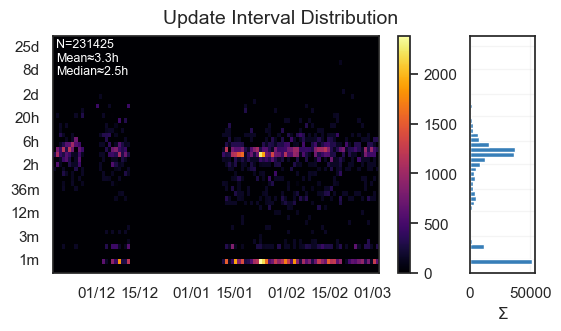

In [123]:
plot_calibration_update_heatmaps(
    df_qubit)

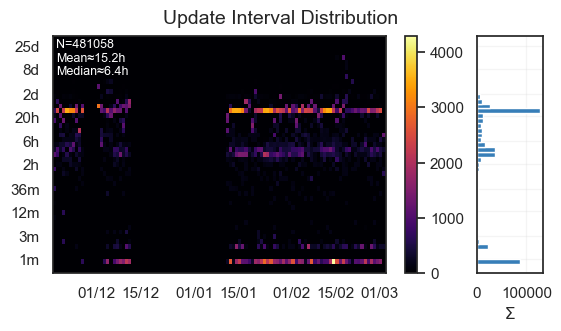

In [124]:
plot_calibration_update_heatmaps(
    df_gate)

In [125]:
import numpy as np

date_max = max(df_qubit["scrape_time"].max(),df_gate["scrape_time"].max())

df_scraping = pd.read_csv("workflow_runs.csv")
df_scraping["created_at"] = pd.to_datetime(df_scraping["created_at"])
df_scraping["date"] = df_scraping["created_at"].dt.date
df_scraping = df_scraping[df_scraping["created_at"]<= date_max]
scrape_days = np.sort(df_scraping[df_scraping["status"] != "failure"]["date"].unique())


def sample_timestamp(scrape_days = scrape_days):
    # Select random date from scrape_days

    random_date = np.random.choice(scrape_days)

    random_seconds = np.random.randint(0, 24 * 60 * 60)

    random_naive_ts = pd.Timestamp(random_date) + pd.to_timedelta(random_seconds, unit="s")
    random_ts = random_naive_ts.tz_localize("UTC")

    return random_ts


def snapshot_qubits(df, timestamp, backend):
    """
    Returns a snapshot of all qubits for a backend at a given timestamp.
    
    df : DataFrame with columns ['entity', 'scrape_time', metrics..., 'backend']
    timestamp : pd.Timestamp
    """
    df_backend = df[df["backend"] == backend].copy()

    # Keep only rows before or at timestamp
    df_before = df_backend[df_backend["scrape_time"] <= timestamp].copy()

    # Sort by entity and scrape_time
    df_before = df_before.sort_values(["entity", "scrape_time"])

    # Take the last observation per entity
    df_snapshot = df_before.groupby("entity").last().reset_index()

    # Optionally remove duration_sec/next_time columns
    df_snapshot = df_snapshot.drop(columns=["next_time", "duration_sec", "gap_flag"], errors="ignore")

    return df_snapshot

In [126]:
timestamp =    sample_timestamp()
snapshot_qubit = snapshot_qubits(df_qubit, timestamp, "ibm_fez")
snapshot_gate = snapshot_qubits(df_gate, timestamp, "ibm_fez")
print(snapshot_gate)


                entity  backend               scrape_time gate    qubits  \
0       ibm_fez|cz|0,1  ibm_fez 2026-01-21 01:28:57+00:00   cz    (0, 1)   
1       ibm_fez|cz|1,0  ibm_fez 2026-01-21 01:28:57+00:00   cz    (1, 0)   
2       ibm_fez|cz|1,2  ibm_fez 2026-01-21 01:28:57+00:00   cz    (1, 2)   
3     ibm_fez|cz|10,11  ibm_fez 2026-01-21 01:28:57+00:00   cz  (10, 11)   
4      ibm_fez|cz|10,9  ibm_fez 2026-01-21 01:28:57+00:00   cz   (10, 9)   
...                ...      ...                       ...  ...       ...   
1791      ibm_fez|x|95  ibm_fez 2026-01-21 01:01:57+00:00    x     (95,)   
1792      ibm_fez|x|96  ibm_fez 2026-01-21 01:01:57+00:00    x     (96,)   
1793      ibm_fez|x|97  ibm_fez 2026-01-21 01:01:57+00:00    x     (97,)   
1794      ibm_fez|x|98  ibm_fez 2026-01-21 01:01:57+00:00    x     (98,)   
1795      ibm_fez|x|99  ibm_fez 2026-01-21 01:01:57+00:00    x     (99,)   

      gate_error   gate_length  arity     qubit  
0       0.014754  6.800000e-08      2

In [ ]:
from tqdm import tqdm

n_samples = 10000
all_snapshots = []

for _ in tqdm(range(n_samples)):
    timestamp = sample_timestamp()
    snapshot_gate = snapshot_qubits(df_gate, timestamp, "ibm_fez")
    
    # flatten the snapshot into a single row
    gate_flatten = snapshot_gate[['entity', 'gate_error', 'gate_length']].set_index('entity').stack().to_frame().T
    gate_flatten.columns = [f"{idx[0]}_{idx[1]}" for idx in gate_flatten.columns]
    
    # add the snapshot timestamp as a column
    gate_flatten['timestamp'] = timestamp
    
    # append to list
    all_snapshots.append(gate_flatten)

# concatenate all snapshots into a single DataFrame
dataset = pd.concat(all_snapshots, ignore_index=True).dropna()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# drop non-numeric columns
X = dataset.drop(columns=['timestamp'])

# standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# keep enough components to explain 95% variance
pca = PCA(n_components=0.95)  
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratios:", pca.explained_variance_ratio_)
print("Number of components:", pca.n_components_)

import pandas as pd

components_df = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# inspect which gates contribute most to each principal component
components_df.head()


Explained variance ratios: [0.07059669 0.05470975 0.05282585 0.04745948 0.04652692 0.0459787
 0.042899   0.04135329 0.04029449 0.0394181  0.03857419 0.03682551
 0.03433148 0.03261425 0.0306765  0.02954363 0.02914833 0.02825541
 0.02667501 0.02628353 0.02483984 0.02322497 0.02023955 0.01600374
 0.0126967  0.00899599 0.00498785 0.00403408 0.00375901 0.003248
 0.00299842 0.00262541 0.00235861 0.00229814 0.00221515 0.00214111
 0.0020337  0.00202171 0.00188058 0.00179377 0.00172813 0.00168133
 0.00167166 0.00161149 0.00158625 0.00154329 0.00149394]
Number of components: 47


,"ibm_fez|cz|0,1_gate_error","ibm_fez|cz|0,1_gate_length","ibm_fez|cz|1,0_gate_error","ibm_fez|cz|1,0_gate_length","ibm_fez|cz|1,2_gate_error","ibm_fez|cz|1,2_gate_length","ibm_fez|cz|10,11_gate_error","ibm_fez|cz|10,11_gate_length","ibm_fez|cz|10,9_gate_error","ibm_fez|cz|10,9_gate_length",...,ibm_fez|x|95_gate_error,ibm_fez|x|95_gate_length,ibm_fez|x|96_gate_error,ibm_fez|x|96_gate_length,ibm_fez|x|97_gate_error,ibm_fez|x|97_gate_length,ibm_fez|x|98_gate_error,ibm_fez|x|98_gate_length,ibm_fez|x|99_gate_error,ibm_fez|x|99_gate_length
PC1,-0.023566,-2.775558e-16,-0.023566,2.220446e-16,0.019919,5.551115e-17,-0.043364,3.469447e-18,0.005209,-2.168404e-19,...,-0.016203,-0.0,0.011981,-0.0,0.023223,-0.0,-0.007189,-0.0,-0.040112,-0.0
PC2,0.040930,-2.775558e-16,0.040930,3.330669e-16,-0.002877,2.775558e-16,-0.002116,-1.942890e-16,-0.018230,4.163336e-17,...,-0.006533,-0.0,-0.008213,-0.0,0.017088,-0.0,-0.000416,-0.0,-0.006119,-0.0
PC3,0.014194,1.665335e-16,0.014194,-5.273559e-16,0.075937,1.110223e-16,0.003126,3.330669e-16,-0.021018,1.110223e-16,...,-0.000364,0.0,-0.012293,0.0,-0.014627,0.0,-0.005779,0.0,-0.004097,0.0
PC4,0.004135,1.387779e-16,0.004135,4.024558e-16,-0.017755,-1.040834e-16,-0.000181,-3.885781e-16,-0.003527,9.714451e-17,...,0.046972,-0.0,-0.012878,-0.0,-0.024300,-0.0,-0.000318,-0.0,0.005406,-0.0
PC5,-0.007369,1.249001e-16,-0.007369,-1.110223e-16,-0.028548,5.759282e-16,-0.035496,-1.665335e-16,-0.012108,-2.983724e-16,...,-0.027136,-0.0,-0.022445,-0.0,0.005798,-0.0,0.020035,-0.0,0.025490,-0.0


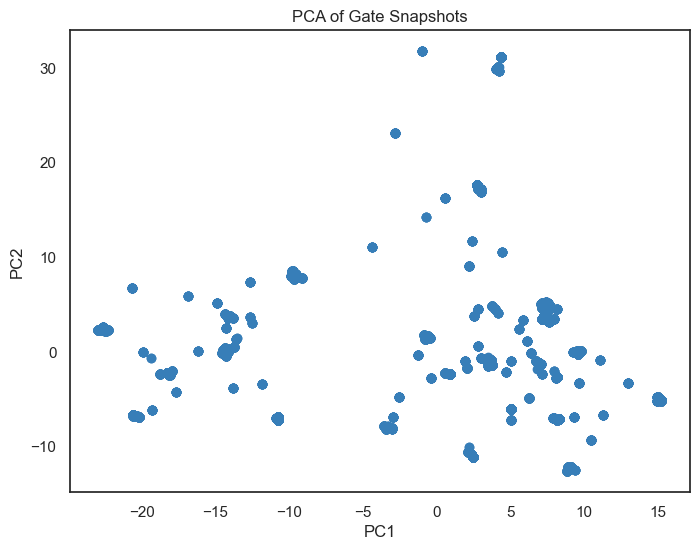

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Gate Snapshots")
plt.show()


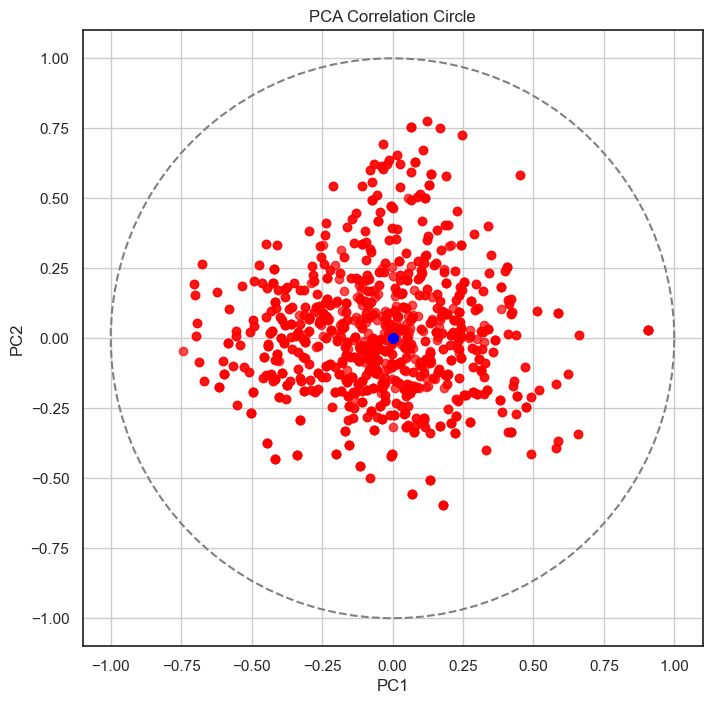

In [ ]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
plt.figure(figsize=(8,8))

# circle
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='gray')

# plot feature vectors
for i, feature in enumerate(X.columns):
    if "error" in feature:
        color = "red"
    elif "length" in feature:
        color = "blue"
    plt.scatter(loadings[i,0], loadings[i,1], color=color, alpha=0.7)
    #plt.text(loadings[i,0]*1.1, loadings[i,1]*1.1, feature, fontsize=8)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Correlation Circle")
plt.grid()
plt.show()
